In [26]:
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import pandas as pd
import numpy as np
import re as regex
import os

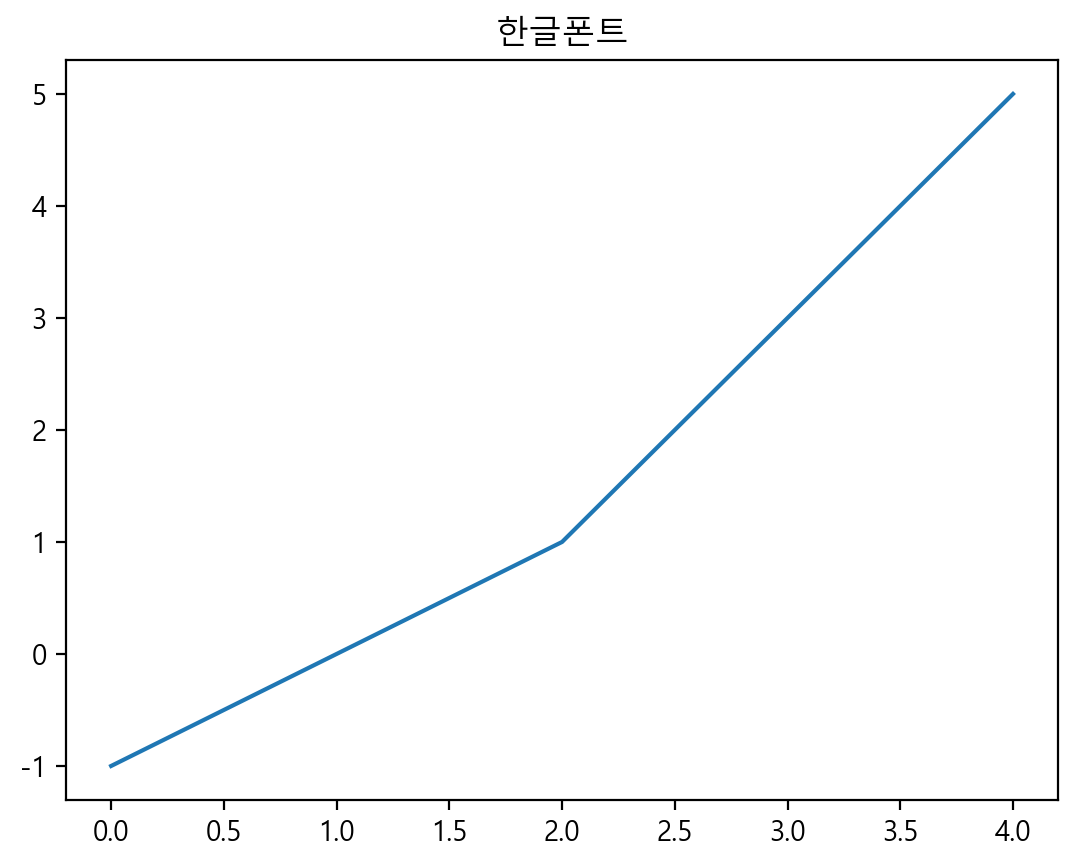

In [27]:
# 한글 안깨지게, 특수문자 안깨지게, 한글 선명하게
plt.rc("font", family="Malgun Gothic")
plt.rc("axes", unicode_minus=False)

# 폰트가 선명하게 보이도록 설정
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("retina")

# 한글폰트와 마이너스 폰트 설정 확인
pd.Series([-1, 0, 1, 3, 5]).plot(title="한글폰트")

# 지수 마이너스 유니코드 안깨지게
import matplotlib as mpl
mpl.rcParams['axes.unicode_minus'] = False

# 경고메시지 스킵
import warnings
warnings.filterwarnings('ignore')

In [28]:
# 작업 경로와 무관하게 데이터 폴더 탐지
analysis_candidates = [
    Path.cwd() / 'data/analysis',
    Path.cwd() / 'Final_proj/daiso/data/analysis',
    Path(r'G:/Final_proj/daiso/data/analysis')
]
base = next((p for p in analysis_candidates if p.exists()), None)
if base is None:
    raise FileNotFoundError('analysis 데이터 경로를 찾지 못했습니다.')

products = pd.read_parquet(base / 'products_full.parquet', engine='pyarrow')
reviews  = pd.read_parquet(base / 'reviews_full.parquet', engine='pyarrow')
promotions  = pd.read_parquet(base / 'promotions_full.parquet', engine='pyarrow')
ingredients  = pd.read_parquet(base / 'ingredients_full.parquet', engine='pyarrow')
users  = pd.read_parquet(base / 'users_full.parquet', engine='pyarrow')

print('analysis base:', base)

analysis base: g:\Final_proj\daiso\data\analysis


In [29]:
# 재무 관련 데이터 불러오기
finance_base = Path.cwd() / "data/finance"

daiso_finance = pd.read_csv(finance_base / "financial_2015_2024.csv")
Economic_Outlook = pd.read_csv(finance_base / "Korean_Economic_Outlook.csv")

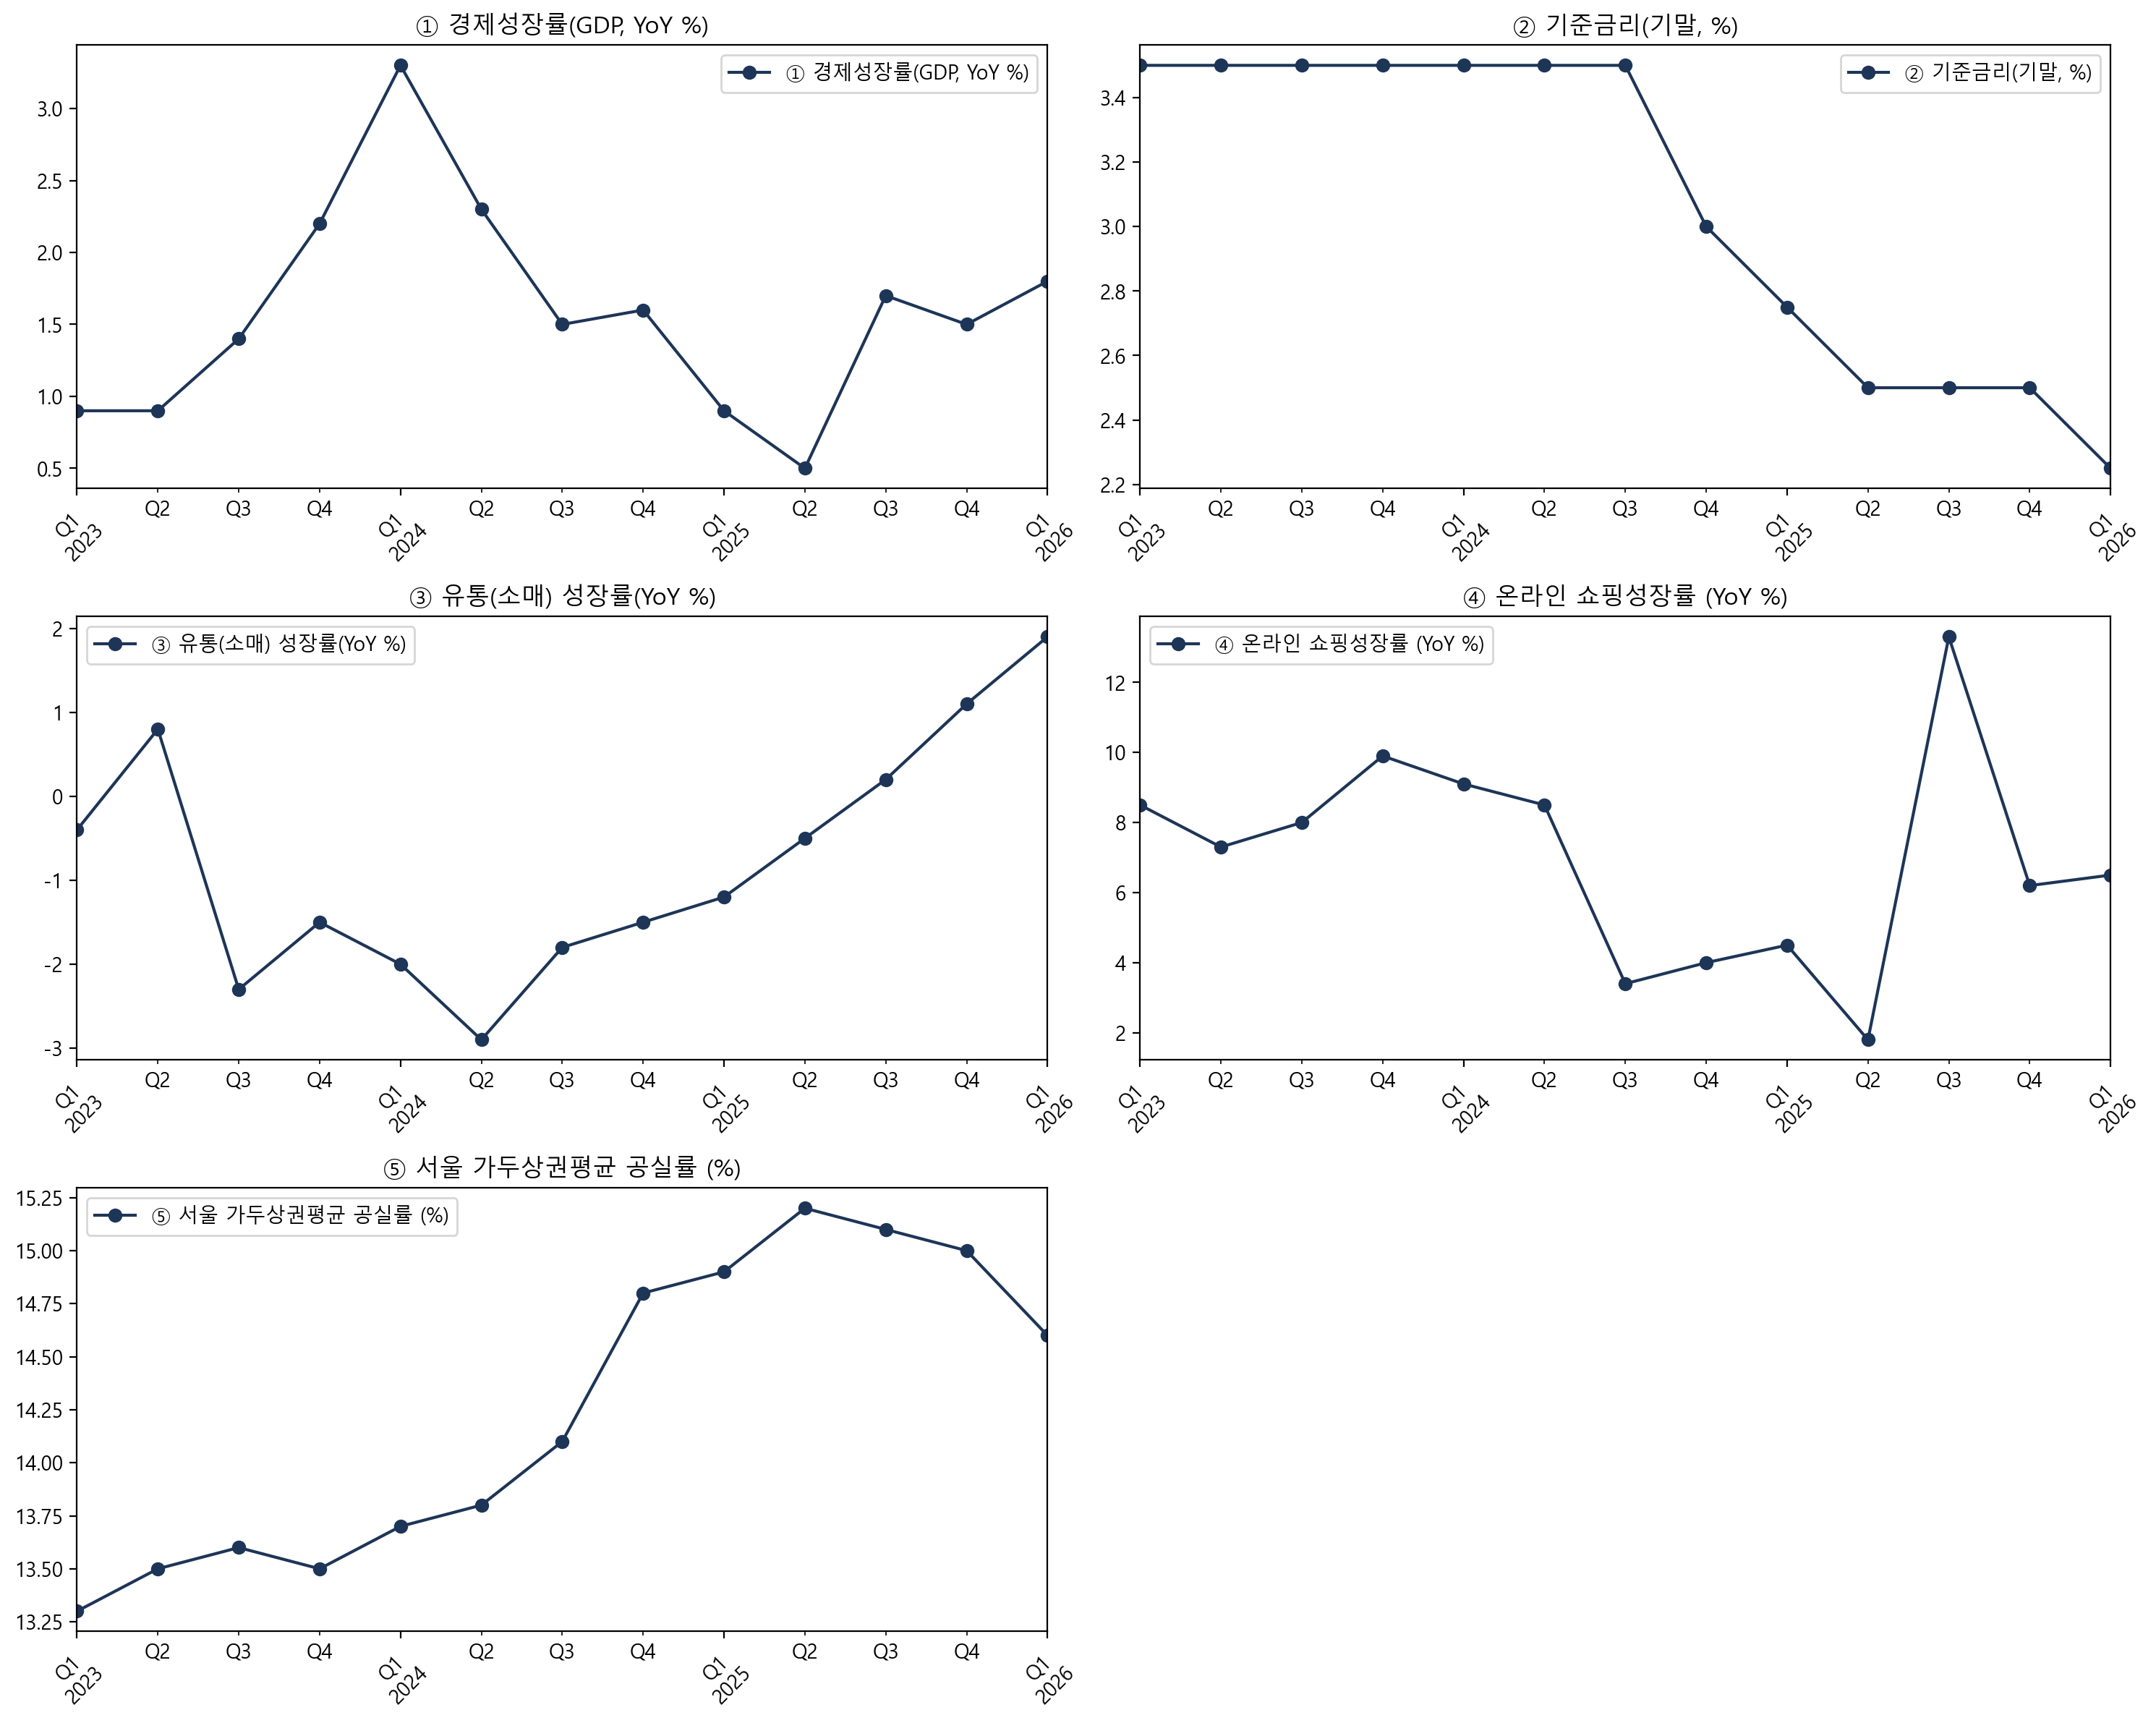

In [30]:
# 6) 거시경제 지표 정제 및 추이 확인
eco = Economic_Outlook.copy()
year_col = eco.columns[0]
quarter_col = eco.columns[1]
indicator_cols = list(eco.columns[2:])

eco[year_col] = pd.to_numeric(eco[year_col], errors='coerce').ffill().astype(int)
eco[quarter_col] = eco[quarter_col].astype(str).str.upper()
eco['quarter_num'] = eco[quarter_col].str.extract(r'(\d+)').astype(int)
eco['year_quarter'] = eco[year_col].astype(str) + '-Q' + eco['quarter_num'].astype(str)
eco['quarter_dt'] = pd.PeriodIndex(eco['year_quarter'], freq='Q').to_timestamp()

for c in indicator_cols:
    eco[c] = pd.to_numeric(eco[c], errors='coerce')

fig, axes = plt.subplots(3, 2, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(indicator_cols):
    eco.plot(x='quarter_dt', y=col, marker='o', ax=axes[i], color='#1d3557')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45)

if len(indicator_cols) < len(axes):
    for j in range(len(indicator_cols), len(axes)):
        axes[j].axis('off')

plt.tight_layout()
plt.show()

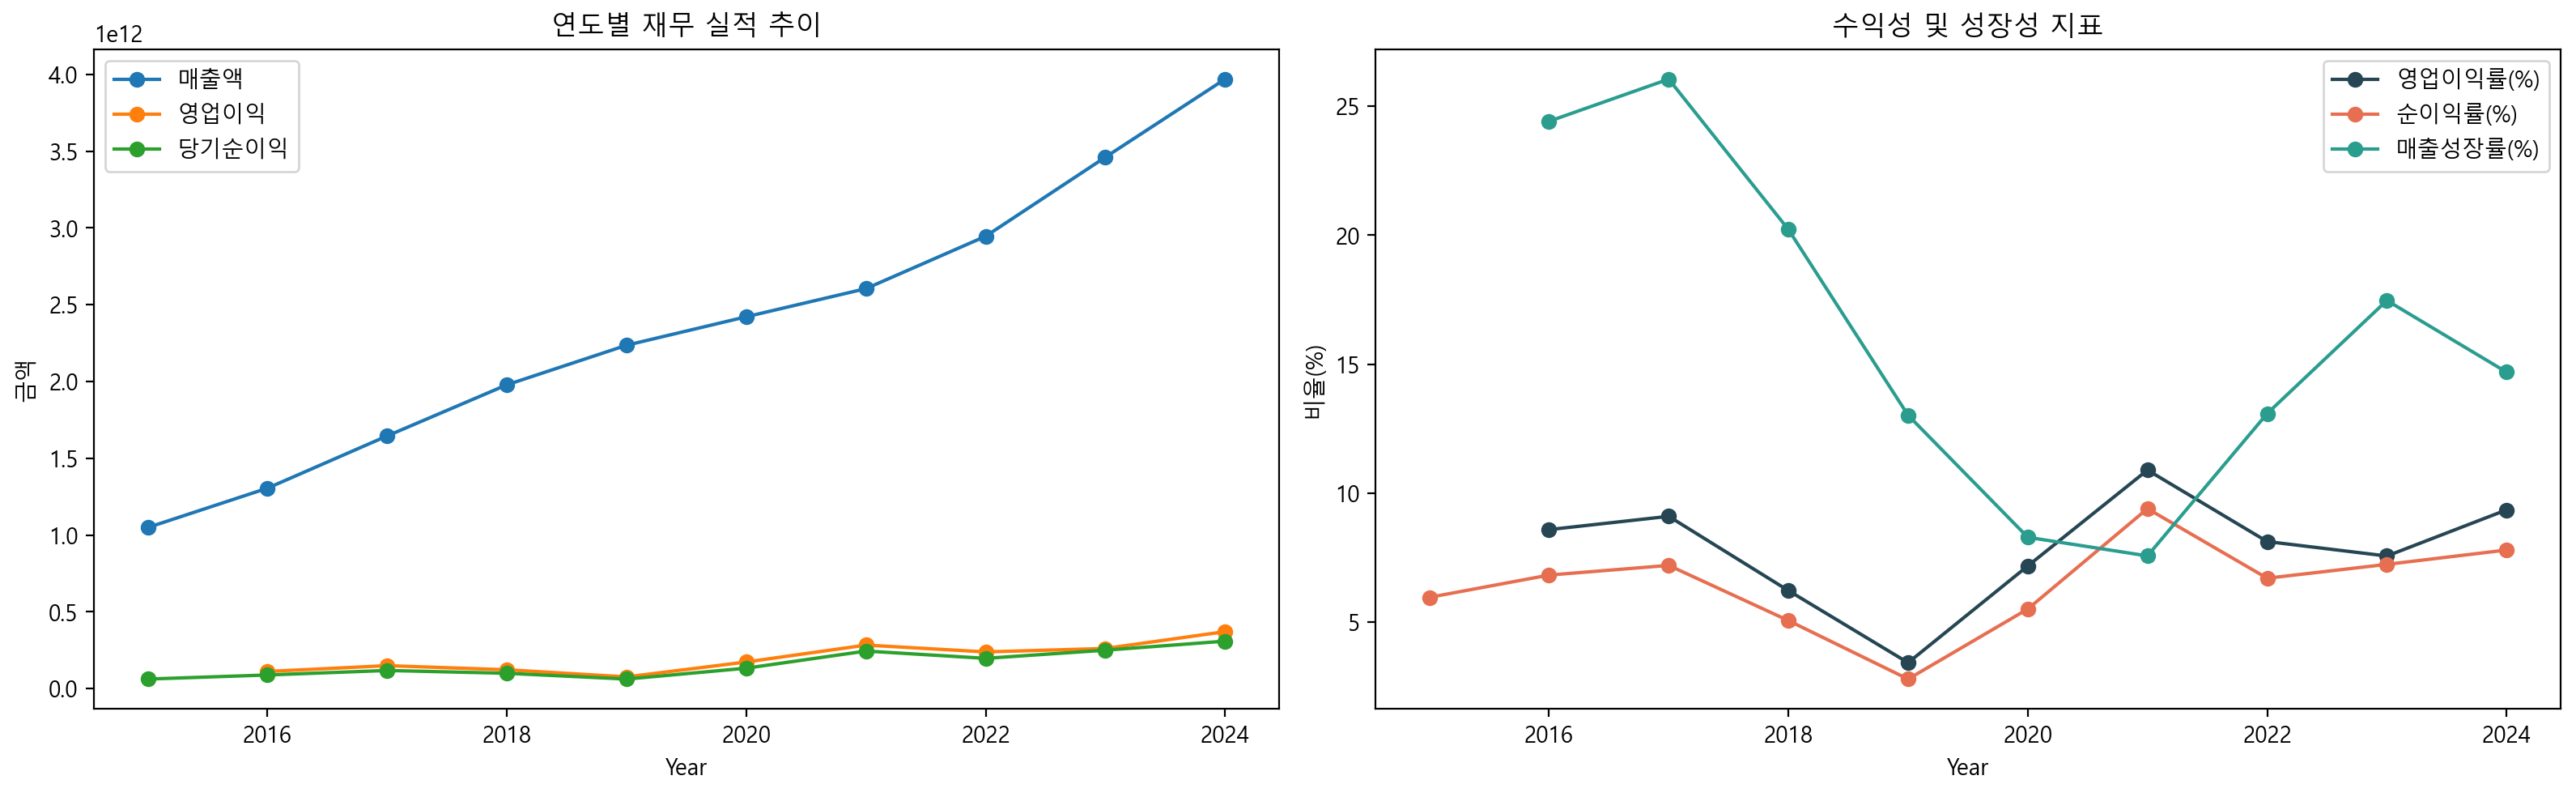

In [31]:
# 7) 다이소 재무데이터 정제 및 연간 성과
fin = daiso_finance.copy()
fin = fin.drop(columns=[c for c in fin.columns if str(c).startswith('Unnamed')], errors='ignore')
year_col = 'Year' if 'Year' in fin.columns else fin.columns[0]
fin[year_col] = pd.to_numeric(fin[year_col], errors='coerce').astype('Int64')

for c in [c for c in fin.columns if c != year_col]:
    fin[c] = pd.to_numeric(fin[c], errors='coerce')

fin = fin.sort_values(year_col).reset_index(drop=True)

sales_col = fin.columns[9]
op_col = fin.columns[13]
net_col = fin.columns[14]
cfo_col = fin.columns[15]

fin['op_margin_pct'] = (fin[op_col] / fin[sales_col] * 100)
fin['net_margin_pct'] = (fin[net_col] / fin[sales_col] * 100)
fin['sales_growth_pct'] = fin[sales_col].pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fin.plot(x=year_col, y=[sales_col, op_col, net_col], marker='o', ax=axes[0])
axes[0].set_title('연도별 재무 실적 추이')
axes[0].set_ylabel('금액')

fin.plot(x=year_col, y=['op_margin_pct', 'net_margin_pct', 'sales_growth_pct'], marker='o', ax=axes[1], color=['#264653', '#e76f51', '#2a9d8f'])
axes[1].set_title('수익성 및 성장성 지표')
axes[1].set_ylabel('비율(%)')
axes[1].legend(['영업이익률(%)', '순이익률(%)', '매출성장률(%)'])

plt.tight_layout()
plt.show()

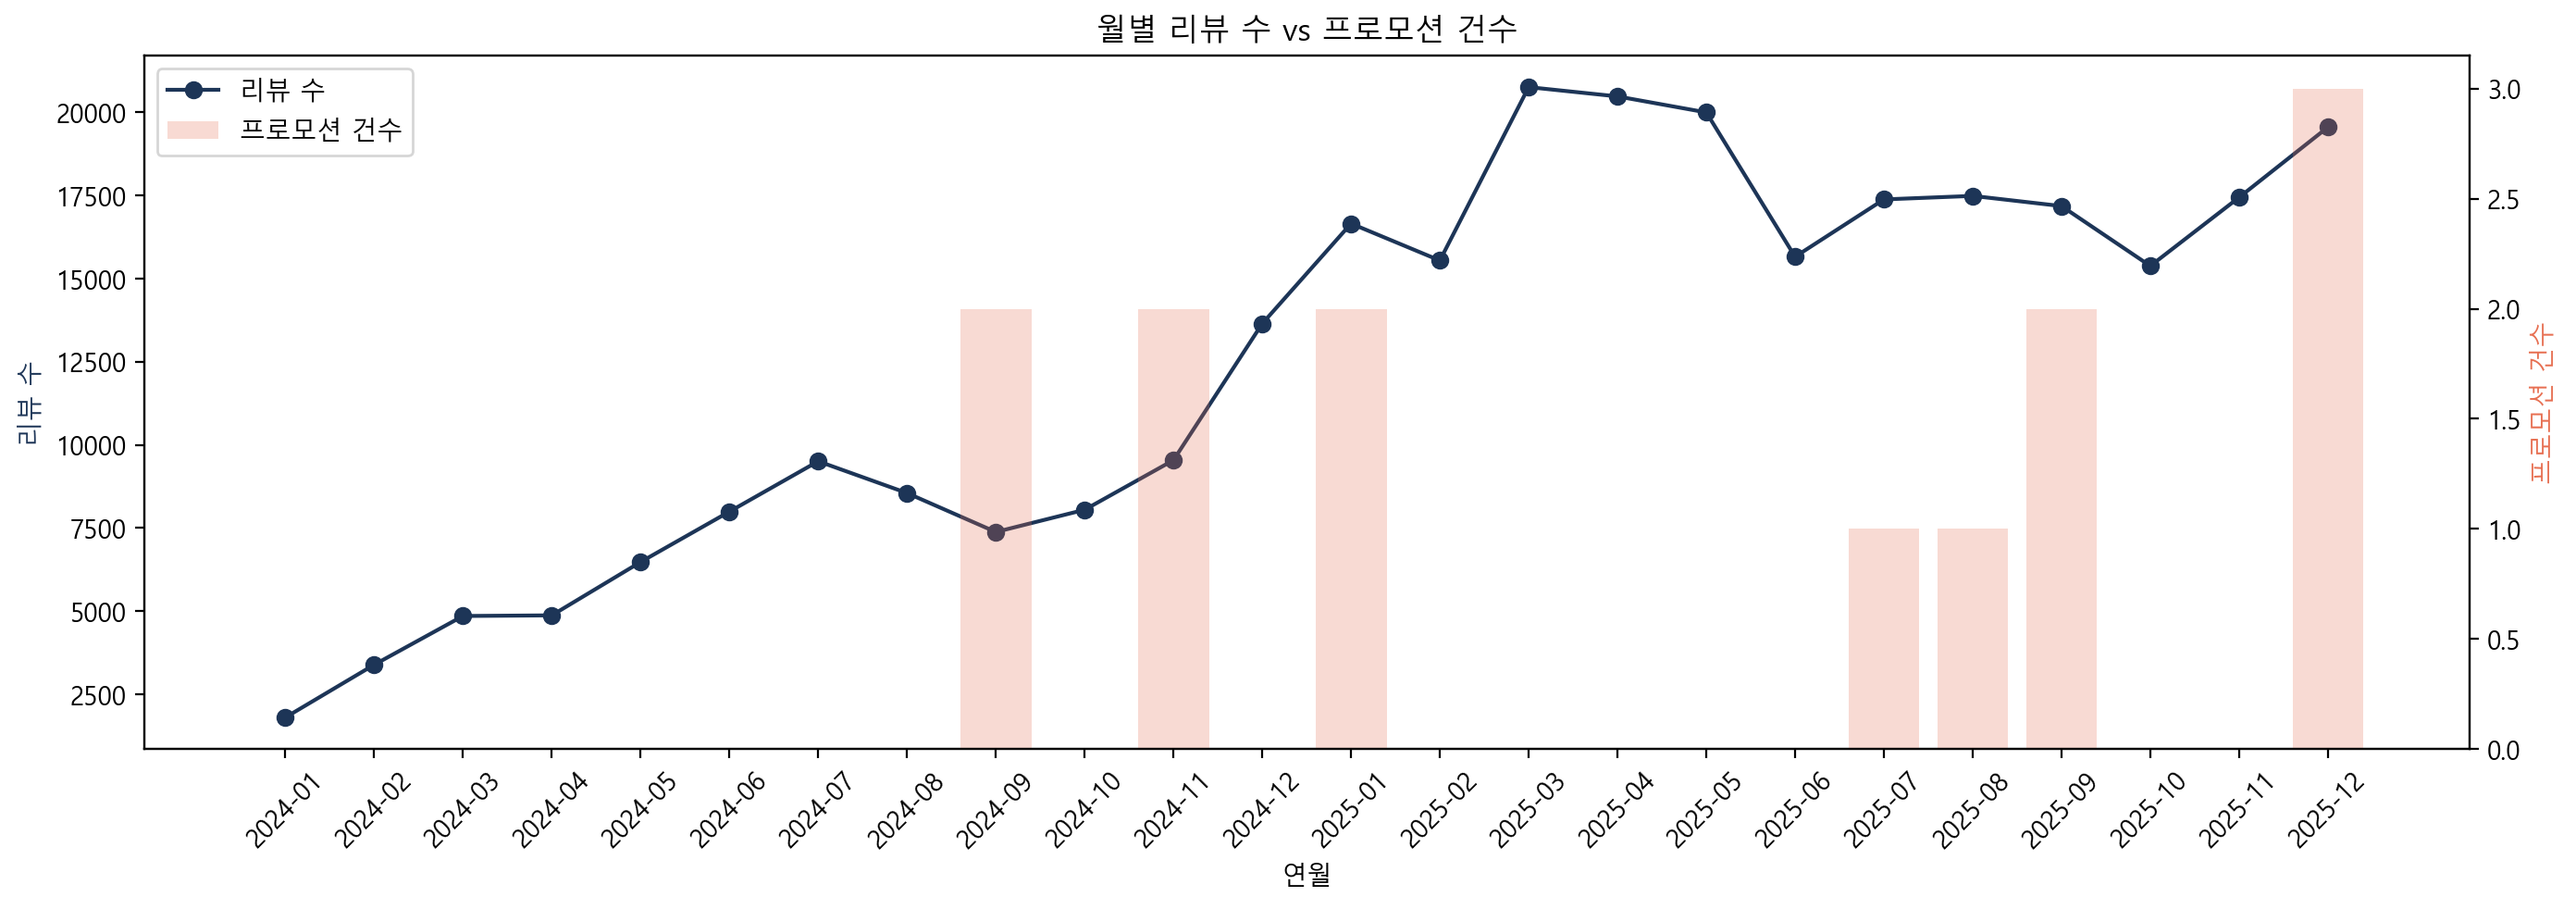

월단위 상관계수(review_cnt, promo_cnt): 0.2548


In [32]:
# 8) 리뷰 시계열과 거시지표 연결 (분기 기준)
rev_ts = reviews.copy()
rev_ts['review_date'] = pd.to_datetime(rev_ts['review_date'], errors='coerce')
ts_cutoff = pd.Timestamp('2025-12-31')
rev_ts = rev_ts.dropna(subset=['review_date'])
rev_ts = rev_ts[rev_ts['review_date'] <= ts_cutoff]
rev_ts['quarter_period'] = rev_ts['review_date'].dt.to_period('Q')

rev_q = (rev_ts.groupby('quarter_period')
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         reorder_rate=('is_reorder','mean'))
    .reset_index())
rev_q['quarter_dt'] = rev_q['quarter_period'].dt.to_timestamp()

eco_q = eco[['year_quarter'] + indicator_cols].copy()
eco_q['quarter_period'] = pd.PeriodIndex(eco_q['year_quarter'], freq='Q')

join_q = (rev_q
    .merge(eco_q.drop(columns=['year_quarter']), on='quarter_period', how='inner')
    .sort_values('quarter_dt'))
join_q['quarter'] = join_q['quarter_period'].astype(str)

corr_cols = ['review_cnt', 'avg_rating', 'reorder_rate'] + indicator_cols
corr_tbl = join_q[corr_cols].corr().round(3)

# 9) 프로모션 이벤트와 리뷰 볼륨 비교 (월 단위)
ts_cutoff = pd.Timestamp('2026-01-31')
promo = pd.read_csv(finance_base / 'promotion_organized.csv')
promo['start_date'] = pd.to_datetime(promo['start_date'], errors='coerce')
promo = promo.dropna(subset=['start_date'])
promo = promo[promo['start_date'] <= ts_cutoff]
promo['year_month'] = promo['start_date'].dt.to_period('M').astype(str)
promo_m = promo.groupby('year_month').size().rename('promo_cnt').reset_index()

rev_m = rev_ts.copy()
rev_m['year_month'] = rev_m['review_date'].dt.to_period('M').astype(str)
rev_m = rev_m.groupby('year_month').agg(review_cnt=('review_id','count')).reset_index()

mon = rev_m.merge(promo_m, on='year_month', how='left').fillna({'promo_cnt':0})
mon = mon.sort_values('year_month')

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(mon['year_month'], mon['review_cnt'], color='#1d3557', marker='o', label='리뷰 수')
ax1.set_ylabel('리뷰 수', color='#1d3557')
ax1.tick_params(axis='x', rotation=45)
ax1.set_xlabel('연월')

ax2 = ax1.twinx()
ax2.bar(mon['year_month'], mon['promo_cnt'], alpha=0.25, color='#e76f51', label='프로모션 건수')
ax2.set_ylabel('프로모션 건수', color='#e76f51')

ax1.set_title('월별 리뷰 수 vs 프로모션 건수')
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

# 연속형간 상관계수이므로 피어슨 상관계수로 계산
print('월단위 상관계수(review_cnt, promo_cnt):', round(mon[['review_cnt','promo_cnt']].corr().iloc[0,1], 4))

### 리뷰수와 프로모션 수로 계산한 월단위 피어슨상관계수가 0.3으로 아주 없지는 않다만, 설득 가능한 수준은 아님

In [33]:
# 10) 공통 분석 모델링용 리뷰 베이스셋
ts_cutoff = pd.Timestamp('2026-01-31')

rv_base = reviews.copy()
rv_base['review_date'] = pd.to_datetime(rv_base['review_date'], errors='coerce')
rv_base = rv_base.dropna(subset=['review_date'])
rv_base = rv_base[rv_base['review_date'] <= ts_cutoff].copy()
rv_base['is_promo_review'] = rv_base['promotion_id'].notna()


rv_master = (rv_base
    .merge(products[['product_code','brand_name','category_1','category_2','price']], on='product_code', how='left')
    .merge(users[['user_id','user_activity_level','user_rating_tendency','review_tenure','user_total_reviews']], on='user_id', how='left'))

display(rv_master[['review_id','review_date','product_code','brand_name','category_2','rating','is_reorder','promotion_id','is_promo_review','user_activity_level']].head())
print('분석 대상 리뷰 수:', len(rv_master))
print('프로모션 리뷰 비중:', round(rv_master['is_promo_review'].mean(), 4))

,review_id,review_date,product_code,brand_name,category_2,rating,is_reorder,promotion_id,is_promo_review,user_activity_level
0,1,2024-01-01,1048275,드롭비,베이스메이크업,5.0,False,NaN,False,VIP
1,2,2024-01-01,1049275,VT,기초스킨케어,5.0,False,NaN,False,VIP
2,3,2024-01-01,1049275,VT,기초스킨케어,5.0,True,NaN,False,VIP
3,4,2024-01-01,1049276,VT,기초스킨케어,5.0,True,NaN,False,VIP
4,5,2024-01-02,1048273,드롭비,베이스메이크업,5.0,False,NaN,False,VIP


분석 대상 리뷰 수: 320643
프로모션 리뷰 비중: 0.077


,review_cnt,avg_rating,reorder_rate,avg_review_len,avg_image_cnt
is_promo_review,,,,,
비프로모션,295961,4.743885,0.294627,35.721007,0.525546
프로모션,24682,4.725549,0.317681,36.455676,0.525970


,review_cnt,avg_rating,reorder_rate
event_type,,,
리뷰이벤트,24438,4.726123,0.318111
구매이벤트,244,4.668033,0.274590


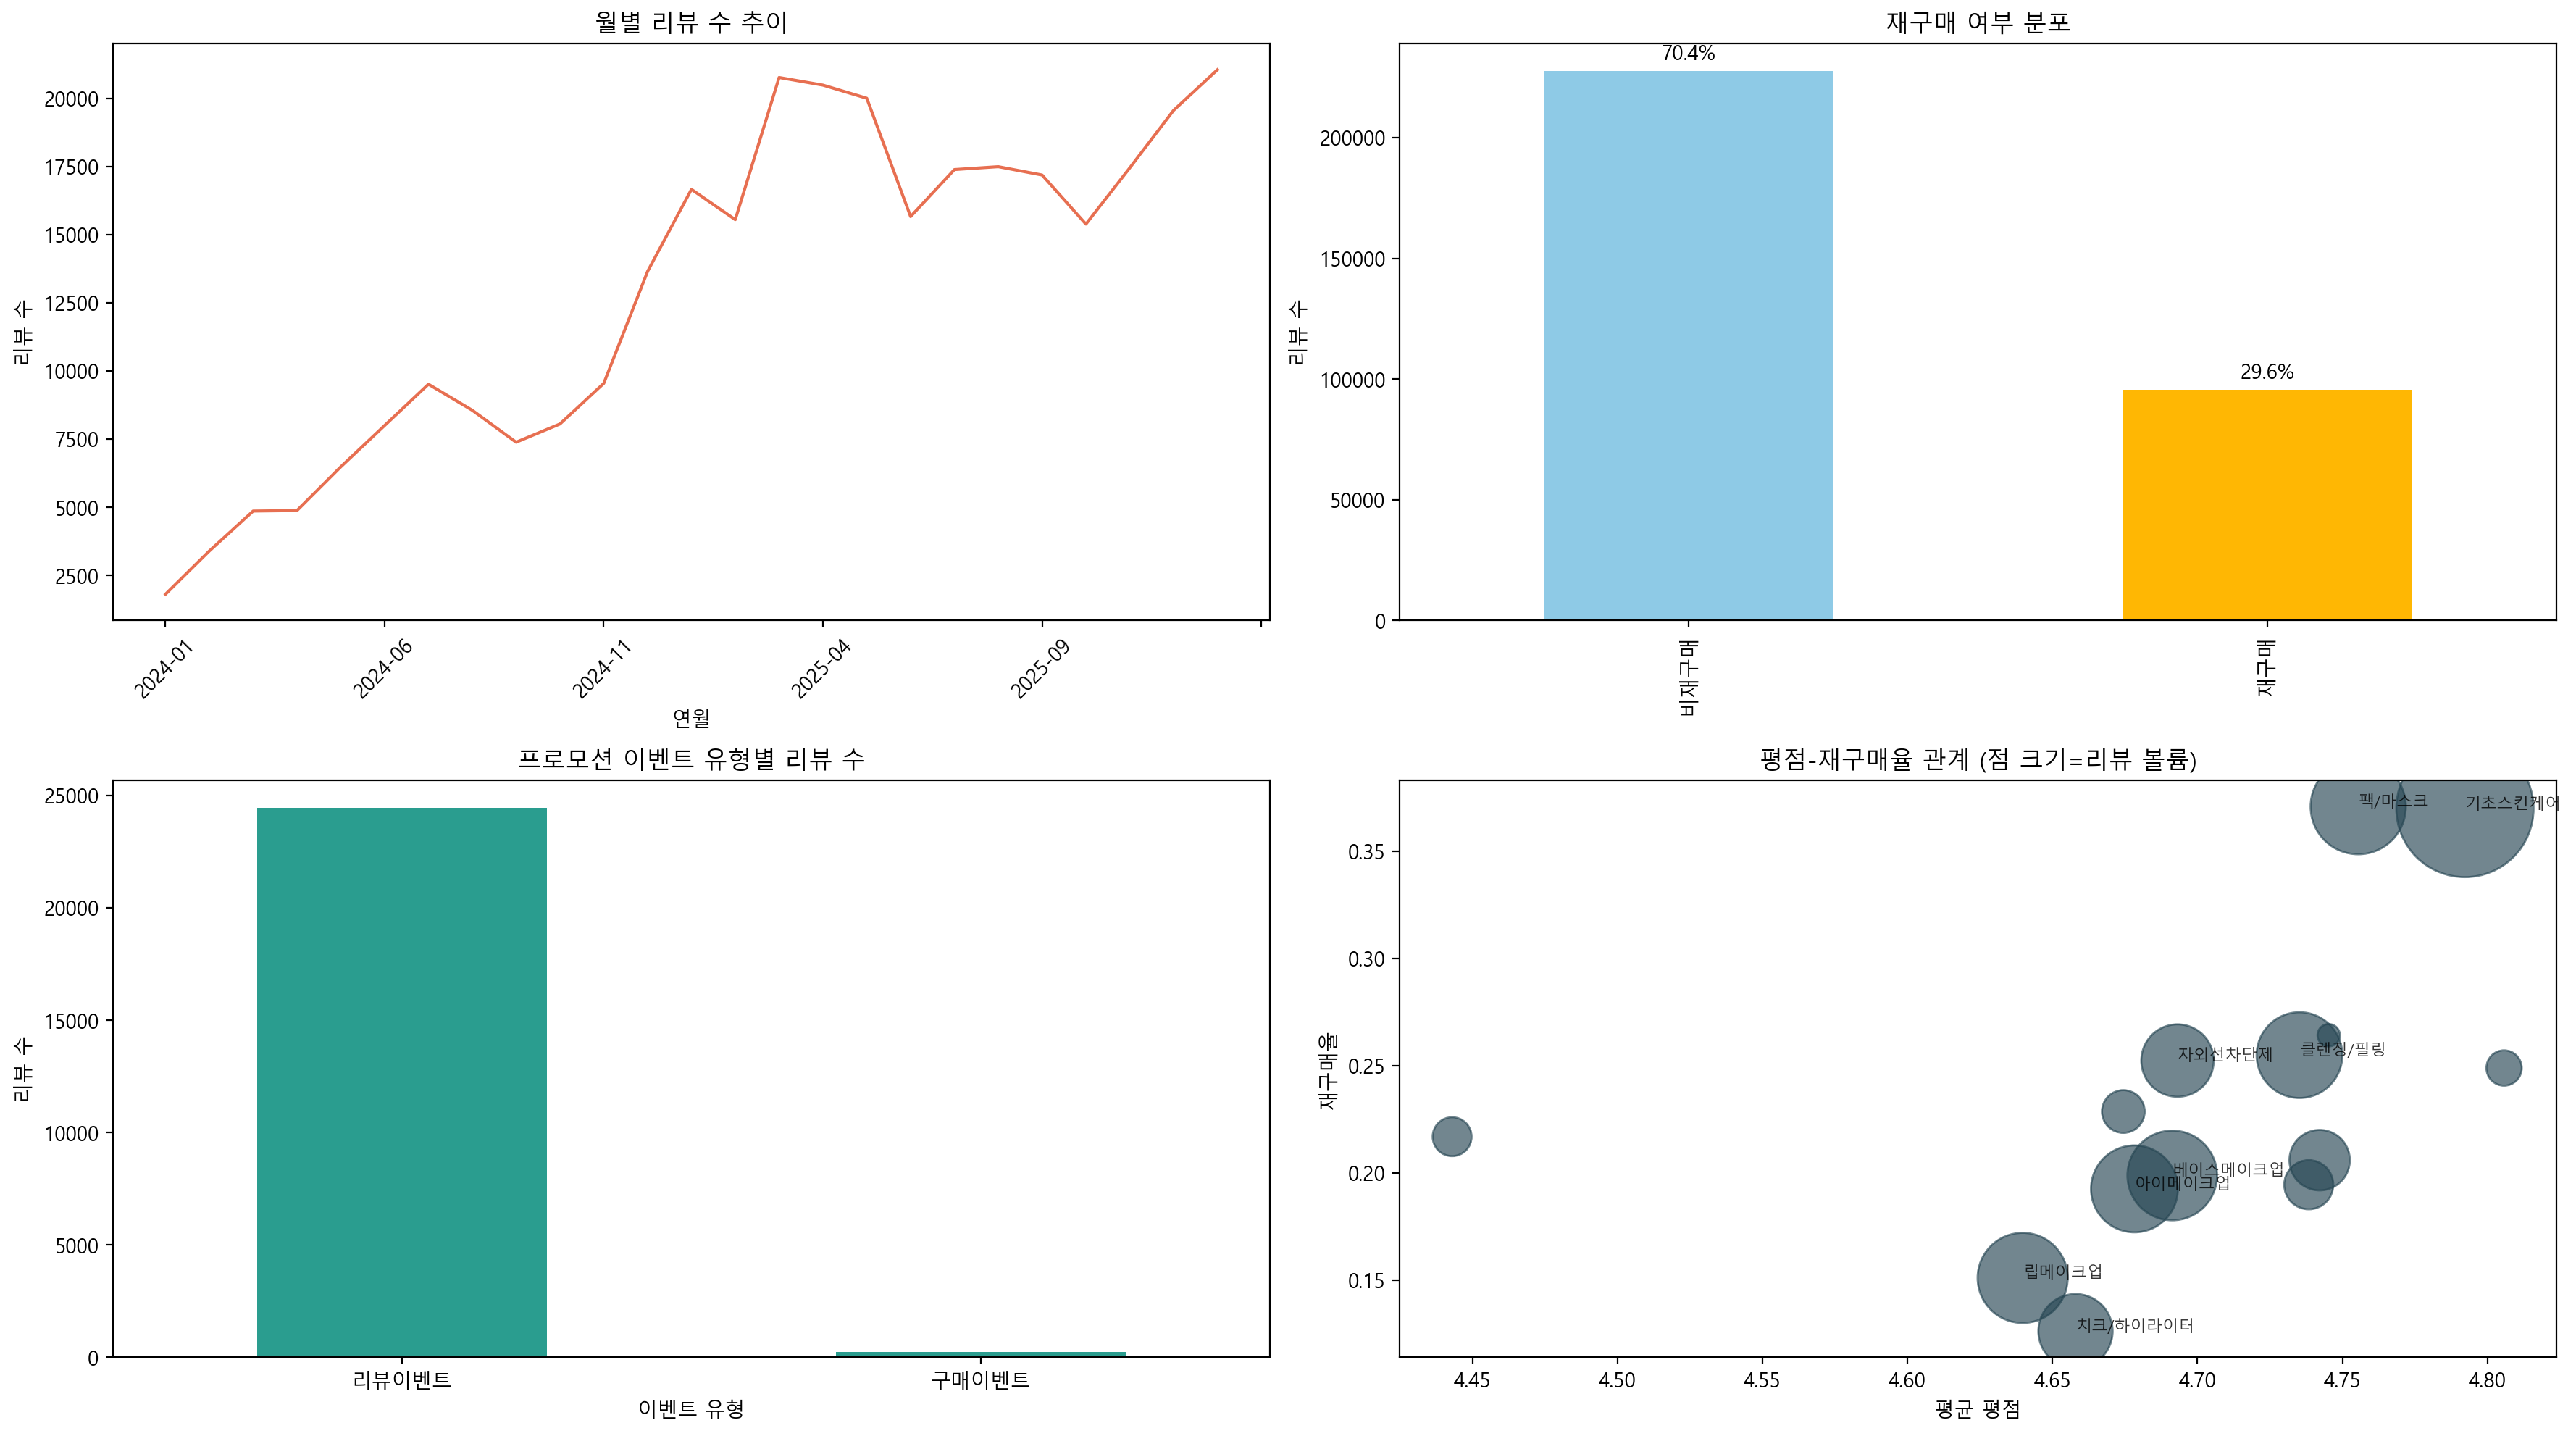

In [34]:
# 4) 카테고리별 성과 (평점/재구매/볼륨)
cat_perf = (reviews
    .merge(products[['product_code','category_1','category_2']], on='product_code', how='left')
    .groupby(['category_1','category_2'])
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         reorder_rate=('is_reorder','mean'))
    .reset_index())

cat_perf_filtered = cat_perf.query('review_cnt >= 100').sort_values('review_cnt', ascending=False)


# 11) 프로모션 노출 효과 (전체/이벤트 유형별)
promo_map = promotions[['promotion_id','event_type','brand_name']].drop_duplicates()
rv_promo = rv_master.merge(promo_map, on='promotion_id', how='left')

overall_cmp = (rv_promo.groupby('is_promo_review')
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         reorder_rate=('is_reorder','mean'),
         avg_review_len=('review_length','mean'),
         avg_image_cnt=('image_count','mean'))
    .rename(index={False:'비프로모션', True:'프로모션'}))
display(overall_cmp)

event_cmp = (rv_promo[rv_promo['is_promo_review']]
    .groupby('event_type')
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         reorder_rate=('is_reorder','mean'))
    .sort_values('review_cnt', ascending=False))
display(event_cmp)

# 3) 리뷰 행동 분석 (평점, 재구매, 길이, 시계열)
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

scatter_df = cat_perf_filtered.copy()
axes[1,1].scatter(scatter_df['avg_rating'], scatter_df['reorder_rate'],
                s=(scatter_df['review_cnt'] ** 0.5) * 12, alpha=0.65, color='#264653')
axes[1,1].set_title('평점-재구매율 관계 (점 크기=리뷰 볼륨)')
axes[1,1].set_xlabel('평균 평점')
axes[1,1].set_ylabel('재구매율')

for _, r in scatter_df.head(8).iterrows():
    axes[1,1].annotate(r['category_2'], (r['avg_rating'], r['reorder_rate']), fontsize=8, alpha=0.8)


s = reviews['is_reorder'].value_counts().rename(index={True: '재구매', False: '비재구매'})
ax = s.plot(kind='bar', ax=axes[0,1], color=['#8ecae6', '#ffb703'])

axes[0,1].set_title('재구매 여부 분포')
axes[0,1].set_xlabel('')
axes[0,1].set_ylabel('리뷰 수')

# 퍼센트 라벨 추가
total = s.sum()
for p in ax.patches:
    h = p.get_height()
    pct = h / total * 100
    ax.annotate(f'{pct:.1f}%',
                (p.get_x() + p.get_width() / 2, h),
                ha='center', va='bottom', xytext=(0, 3), textcoords='offset points')

if len(event_cmp) > 0:
    event_cmp['review_cnt'].plot(kind='bar', ax=axes[1,0], color='#2a9d8f')
    axes[1,0].set_title('프로모션 이벤트 유형별 리뷰 수')
    axes[1,0].set_xlabel('이벤트 유형')
    axes[1,0].set_ylabel('리뷰 수')
    axes[1,0].tick_params(axis='x', rotation=0)

tmp_reviews = reviews.copy()
tmp_reviews['review_date'] = pd.to_datetime(tmp_reviews['review_date'], errors='coerce')
ts_cutoff = pd.Timestamp('2026-01-31')
tmp_reviews = tmp_reviews.dropna(subset=['review_date'])
tmp_reviews = tmp_reviews[tmp_reviews['review_date'] <= ts_cutoff]
monthly_reviews = (tmp_reviews
    .assign(year_month=lambda d: d['review_date'].dt.to_period('M').astype(str))
    .groupby('year_month')['review_id'].count())
monthly_reviews.plot(ax=axes[0,0], color='#e76f51')
axes[0,0].set_title('월별 리뷰 수 추이')
axes[0,0].set_xlabel('연월')
axes[0,0].set_ylabel('리뷰 수')
axes[0,0].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

1. 다이소물 오픈 후 리뷰수는 꾸준히 상승 중이다
2. 전체 구매자 중 상당수가(약 30%) 재구매 고객이다
3. 구매이벤트에 속한 리뷰는 244개에 불과하다..
4. 재구매가 가장 활발한 제품은 기초스킨케어와 팩/마스크 (평점-재구매율 관계도 가장 두드러진다)

,promotion_id,brand_name,event_type,start_date,pre_4w_reviews,post_4w_reviews,uplift_abs,uplift_pct
7,10,태그,리뷰이벤트,2025-09-08,663,1208,545,82.202112
5,7,본셉,리뷰이벤트,2025-07-01,1995,2403,408,20.451128
2,3,메디필,구매이벤트,2024-11-13,177,342,165,93.220339
8,11,에이솔루션,리뷰이벤트,2025-12-01,140,212,72,51.428571
9,12,본셉,리뷰이벤트,2025-12-01,1631,1698,67,4.107909
1,2,바이 오디-티디,리뷰이벤트,2024-09-11,49,112,63,128.571429
10,13,프렙 바이 비레디,리뷰이벤트,2025-12-01,60,97,37,61.666667
6,9,랩잇,리뷰이벤트,2025-09-08,128,114,-14,-10.937500
4,6,비프루브,구매이벤트,2025-01-21,145,121,-24,-16.551724
3,5,VT,리뷰이벤트,2025-01-21,1802,1766,-36,-1.997780


,brand_name,event_cnt,pre_4w_reviews,post_4w_reviews,mean_uplift_abs,median_uplift_abs,mean_uplift_pct,total_uplift_abs,total_uplift_pct
7,태그,1,663,1208,545.0,545.0,82.202112,545,82.202112
4,본셉,2,3626,4101,237.5,237.5,12.279519,475,13.099835
2,메디필,1,177,342,165.0,165.0,93.220339,165,93.220339
6,에이솔루션,1,140,212,72.0,72.0,51.428571,72,51.428571
3,바이 오디-티디,1,49,112,63.0,63.0,128.571429,63,128.571429
8,프렙 바이 비레디,1,60,97,37.0,37.0,61.666667,37,61.666667
1,랩잇,1,128,114,-14.0,-14.0,-10.937500,-14,-10.937500
5,비프루브,1,145,121,-24.0,-24.0,-16.551724,-24,-16.551724
0,VT,2,4309,3800,-254.5,-254.5,-10.432476,-509,-11.812485


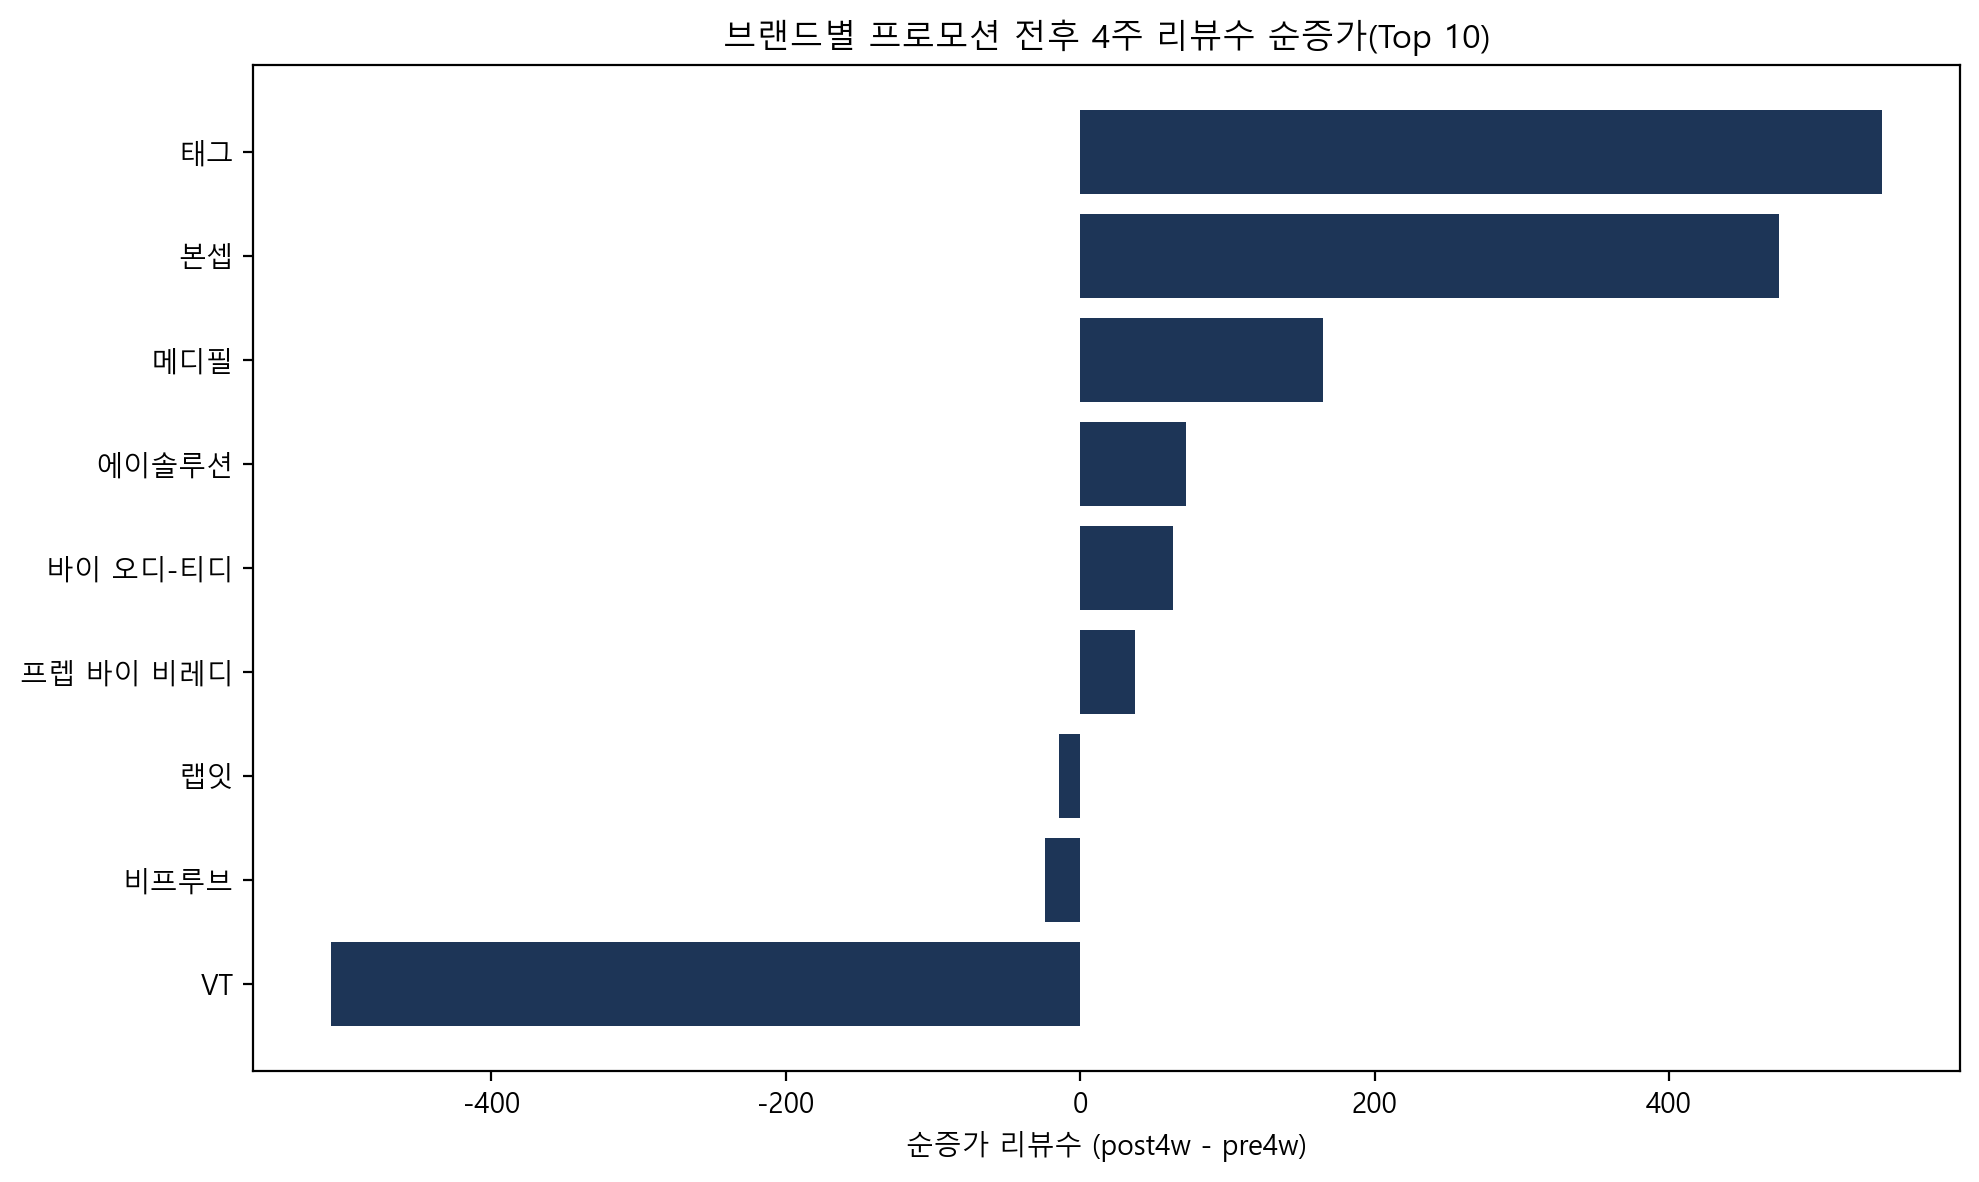

In [35]:
# 브랜드별 프로모션 전후 리뷰수 분석

# 1) 이벤트 테이블 정리
events = promotions[['promotion_id', 'brand_name', 'start_date', 'event_type']].drop_duplicates().copy()
events['start_date'] = pd.to_datetime(events['start_date'], errors='coerce')
events = events.dropna(subset=['brand_name', 'start_date'])

# 4주까지 관측 가능한 이벤트만
events = events[events['start_date'] <= (ts_cutoff - pd.Timedelta(days=28))].copy()

# 2) 브랜드-일자 리뷰수 집계
brand_daily = (rv_master
    .groupby(['brand_name', 'review_date'])['review_id']
    .count()
    .rename('review_cnt')
    .reset_index())

# 빠른 조회용
brand_daily_map = {b: g.set_index('review_date')['review_cnt'] for b, g in brand_daily.groupby('brand_name')}

# 3) 이벤트별 pre/4주 비교
rows = []
for ev in events.itertuples(index=False):
    if ev.brand_name not in brand_daily_map:
        continue

    s = brand_daily_map[ev.brand_name]

    pre_start = ev.start_date - pd.Timedelta(days=28)
    pre_end   = ev.start_date - pd.Timedelta(days=1)
    post_start = ev.start_date
    post_end   = ev.start_date + pd.Timedelta(days=27)

    pre = s.loc[(s.index >= pre_start) & (s.index <= pre_end)].sum()
    post = s.loc[(s.index >= post_start) & (s.index <= post_end)].sum()

    rows.append({
        'promotion_id': ev.promotion_id,
        'brand_name': ev.brand_name,
        'event_type': ev.event_type,
        'start_date': ev.start_date,
        'pre_4w_reviews': pre,
        'post_4w_reviews': post,
        'uplift_abs': post - pre,
        'uplift_pct': np.nan if pre == 0 else (post - pre) / pre * 100
    })

event_uplift = pd.DataFrame(rows)
display(event_uplift.sort_values('uplift_abs', ascending=False).head(20))

# 4) 브랜드 단위 요약
brand_uplift = (event_uplift.groupby('brand_name')
    .agg(
        event_cnt=('promotion_id', 'count'),
        pre_4w_reviews=('pre_4w_reviews', 'sum'),
        post_4w_reviews=('post_4w_reviews', 'sum'),
        mean_uplift_abs=('uplift_abs', 'mean'),
        median_uplift_abs=('uplift_abs', 'median'),
        mean_uplift_pct=('uplift_pct', 'mean')
    )
    .reset_index())

brand_uplift['total_uplift_abs'] = brand_uplift['post_4w_reviews'] - brand_uplift['pre_4w_reviews']
brand_uplift['total_uplift_pct'] = np.where(
    brand_uplift['pre_4w_reviews'] == 0,
    np.nan,
    (brand_uplift['total_uplift_abs'] / brand_uplift['pre_4w_reviews']) * 100
)

display(brand_uplift.sort_values('total_uplift_abs', ascending=False))

# 5) 시각화 (상위 10)
plot_df = brand_uplift.sort_values('total_uplift_abs', ascending=False).head(10).sort_values('total_uplift_abs')

plt.figure(figsize=(10, 6))
plt.barh(plot_df['brand_name'], plot_df['total_uplift_abs'], color='#1d3557')
plt.title('브랜드별 프로모션 전후 4주 리뷰수 순증가(Top 10)')
plt.xlabel('순증가 리뷰수 (post4w - pre4w)')
plt.ylabel('')
plt.tight_layout()
plt.show()


,product_code,brand_name,name,category_2,review_cnt,avg_rating,reorder_rate,one_star_rate,is_allergic_count,risk_score
579,1061905,코드글로컬러,[02 피치] 코드글로컬러 컨실레놀 10 g,베이스메이크업,96,4.229167,0.062500,0.093750,6.0,0.990036
147,1043656,데일리콤마,데일리콤마 오드 퍼퓸(미스티가든) 30 ml,남성향수,117,4.247863,0.111111,0.111111,5.0,0.969818
470,1060676,손앤박,손앤박 아티 스프레드 하이라이터 밤(01 클리어),치크/하이라이터,472,4.514831,0.114407,0.052966,7.0,0.943723
471,1060677,손앤박,손앤박 아티 스프레드 하이라이터 밤(02 선라이즈),치크/하이라이터,217,4.447005,0.142857,0.055300,7.0,0.935766
149,1043658,데일리콤마,데일리콤마 오 드 퍼퓸 30 ml 머스키시더,남성향수,94,4.446809,0.148936,0.063830,5.0,0.932920
803,1068733,클리덤,클리덤 리포좀 비타민C 기미 앰플 밤 팩트(21호) 10 g,베이스메이크업,190,4.489474,0.152632,0.057895,6.0,0.928102
641,1062776,입큰,입큰 퍼스널 퍼퓸 파우더 블러셔 아이시 베리,치크/하이라이터,92,4.500000,0.097826,0.043478,2.0,0.919599
447,1060653,투에딧,[선우 PICK] 투에딧 바이 루나 스머징 립앤치크 멀티 스틱(01 멜로우살몬),립메이크업,102,4.401961,0.127451,0.078431,1.0,0.914161
584,1061910,코드글로컬러,[02 애플팝] 코드글로컬러 프루티 볼륨 립글로스,립메이크업,81,4.518519,0.111111,0.037037,3.0,0.907956
524,1061477,드롭비,[01 라이트 베이지] 드롭비 컬러즈 커버픽 파운데이션 리뉴 35 g,베이스메이크업,86,4.395349,0.186047,0.069767,3.0,0.906131


,prod_cnt,avg_risk
category_2,,
남성향수,6,0.893990
립메이크업,105,0.625933
치크/하이라이터,54,0.619609
베이스메이크업,73,0.587833
자외선차단제,33,0.586231
아이메이크업,82,0.577676
립케어,19,0.498054
남성용면도기,8,0.489220
남성스킨케어,13,0.462462


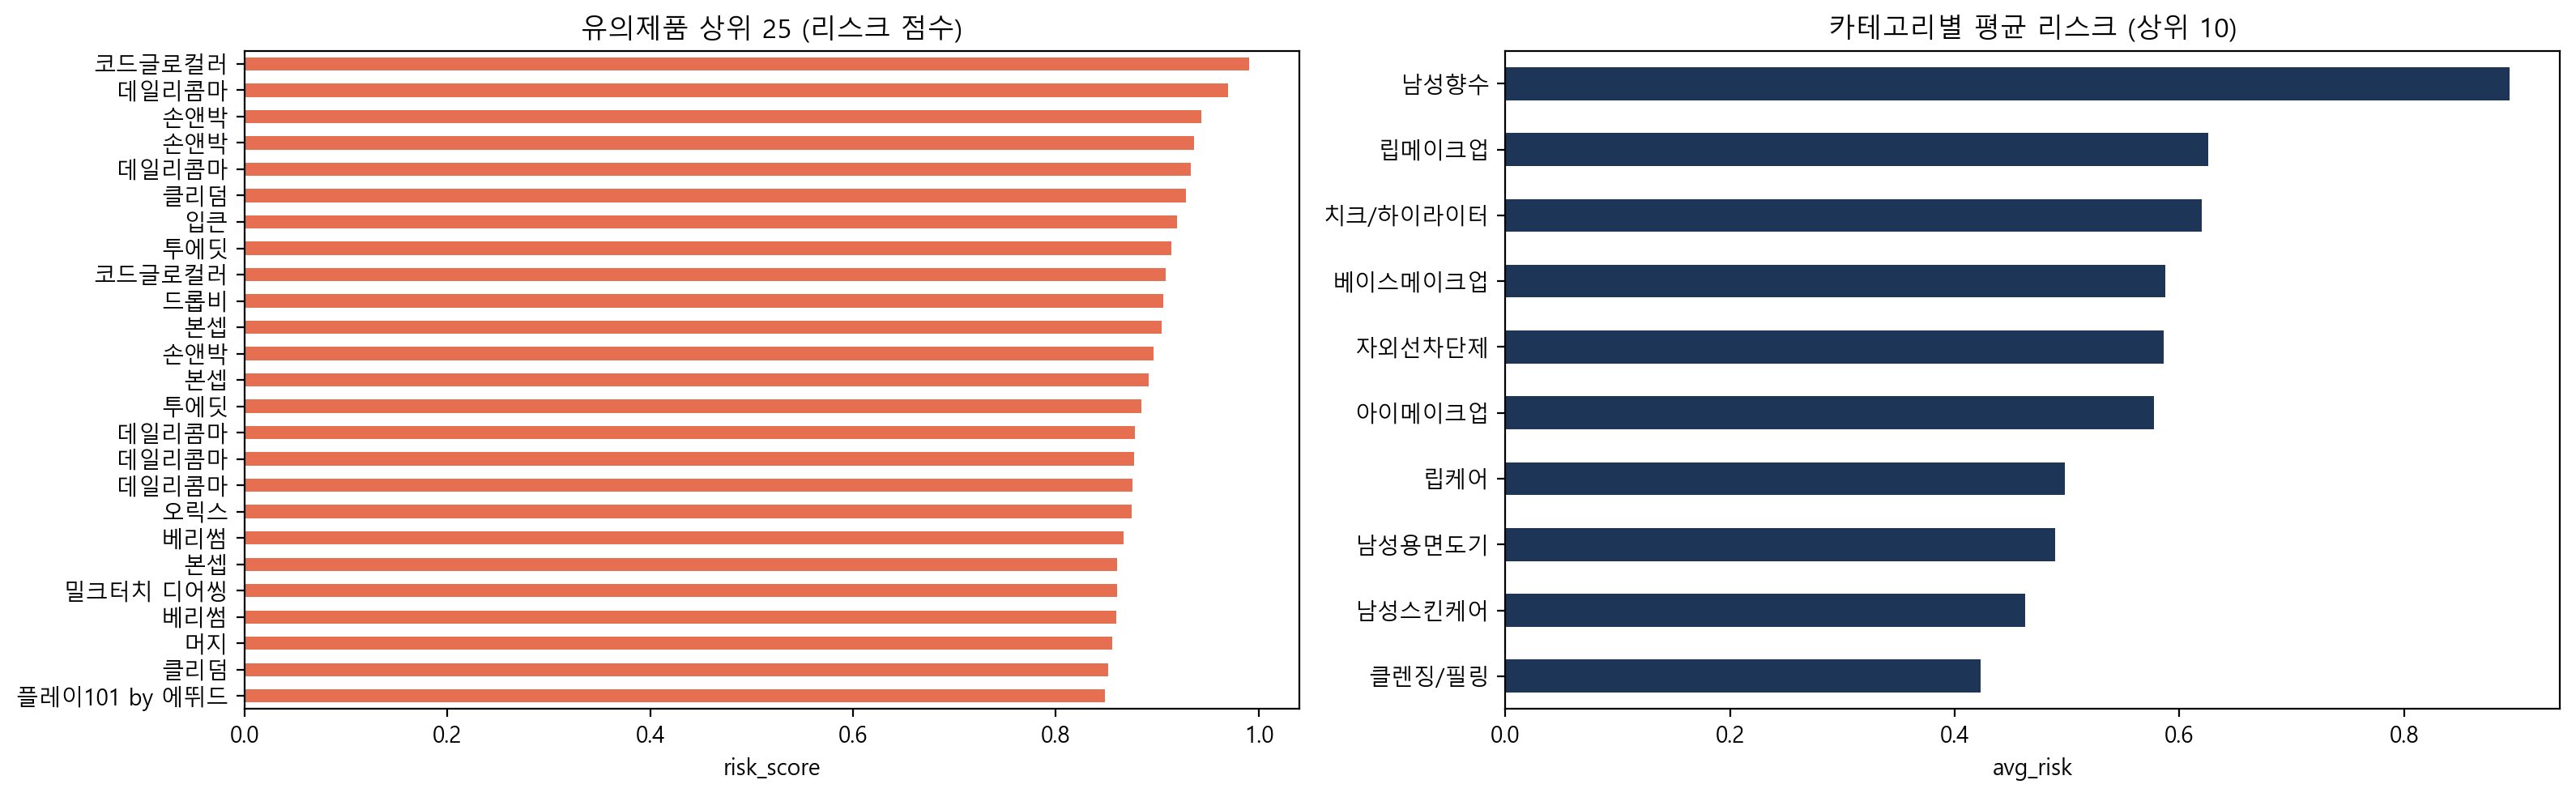

In [36]:
# 20) 유의제품 필터링 (비감성 지표 기반 리스크 점수)

# 5) 성분 리스크와 리뷰 성과 연결
ing = ingredients.copy()
if pd.api.types.is_numeric_dtype(ing['is_allergic']):
    ing['is_allergic_bin'] = ing['is_allergic'].fillna(0).astype(float).gt(0)
else:
    ing['is_allergic_bin'] = ing['is_allergic'].astype(str).str.lower().isin(['1','true','y','yes'])

prod_risk = (ing.groupby('product_code')
    .agg(is_allergic_count=('is_allergic_bin','sum'),
         ingredient_cnt=('ingredient_id','count'))
    .reset_index())

prod_perf = (reviews.groupby('product_code')
    .agg(avg_rating=('rating','mean'),
         review_cnt=('review_id','count'),
         reorder_rate=('is_reorder','mean'))
    .reset_index())

risk_df = (prod_risk
    .merge(prod_perf, on='product_code', how='left')
    .merge(products[['product_code','name','brand_name','category_2']], on='product_code', how='left'))

risk_src = rv_master.merge(risk_df[['product_code','name','is_allergic_count']], on='product_code', how='left')

prod_risk = (risk_src.groupby('product_code')
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         reorder_rate=('is_reorder','mean'),
         one_star_rate=('rating', lambda s: (s <= 2).mean()),
         rating_std=('rating','std'),
         image_ratio=('image_count', lambda s: (s > 0).mean()),
         is_allergic_count=('is_allergic_count','first'),
         price=('price','first'),
         name=('name','first'),
         brand_name=('brand_name','first'),
         category_2=('category_2','first'))
    .reset_index())

prod_risk['rating_std'] = prod_risk['rating_std'].fillna(0)
prod_risk['is_allergic_count'] = prod_risk['is_allergic_count'].fillna(0)

risk_base = prod_risk[prod_risk['review_cnt'] >= 80].copy()

for col in ['one_star_rate','rating_std','is_allergic_count']:
    risk_base[col + '_rank'] = risk_base[col].rank(pct=True)
for col in ['reorder_rate','avg_rating']:
    risk_base[col + '_rank'] = risk_base[col].rank(pct=True)

risk_base['risk_score'] = (
    0.35 * risk_base['one_star_rate_rank'] +
    0.20 * risk_base['rating_std_rank'] +
    0.20 * risk_base['is_allergic_count_rank'] +
    0.15 * (1 - risk_base['reorder_rate_rank']) +
    0.10 * (1 - risk_base['avg_rating_rank'])
)

risk_df = risk_base.sort_values('risk_score', ascending=False).head(25)
display(risk_df[['product_code','brand_name','name','category_2','review_cnt','avg_rating','reorder_rate','one_star_rate','is_allergic_count','risk_score']])

cat_risk = (risk_base.groupby('category_2')
    .agg(prod_cnt=('product_code','count'),
         avg_risk=('risk_score','mean'))
    .sort_values('avg_risk', ascending=False))
display(cat_risk.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
risk_df.sort_values('risk_score').plot(x='brand_name', y='risk_score', kind='barh', ax=axes[0], color='#e76f51', legend=False)
axes[0].set_title('유의제품 상위 25 (리스크 점수)')
axes[0].set_xlabel('risk_score')
axes[0].set_ylabel('')

cat_risk.head(10).sort_values('avg_risk').plot(y='avg_risk', kind='barh', ax=axes[1], color='#1d3557', legend=False)
axes[1].set_title('카테고리별 평균 리스크 (상위 10)')
axes[1].set_xlabel('avg_risk')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

one_star_rate (별점 2 이하 비율) 35% <br>
rating_std (별점 변동성) 20% <br>
allergic_count (알러지 유발 성분 수) 20% <br>


reorder_rate (재구매율) 15% <br>
낮을수록 위험이므로 1 - rank 처리 <br>


avg_rating (평균 평점) 10% <br>
낮을수록 위험이므로 1 - rank 처리 <br>

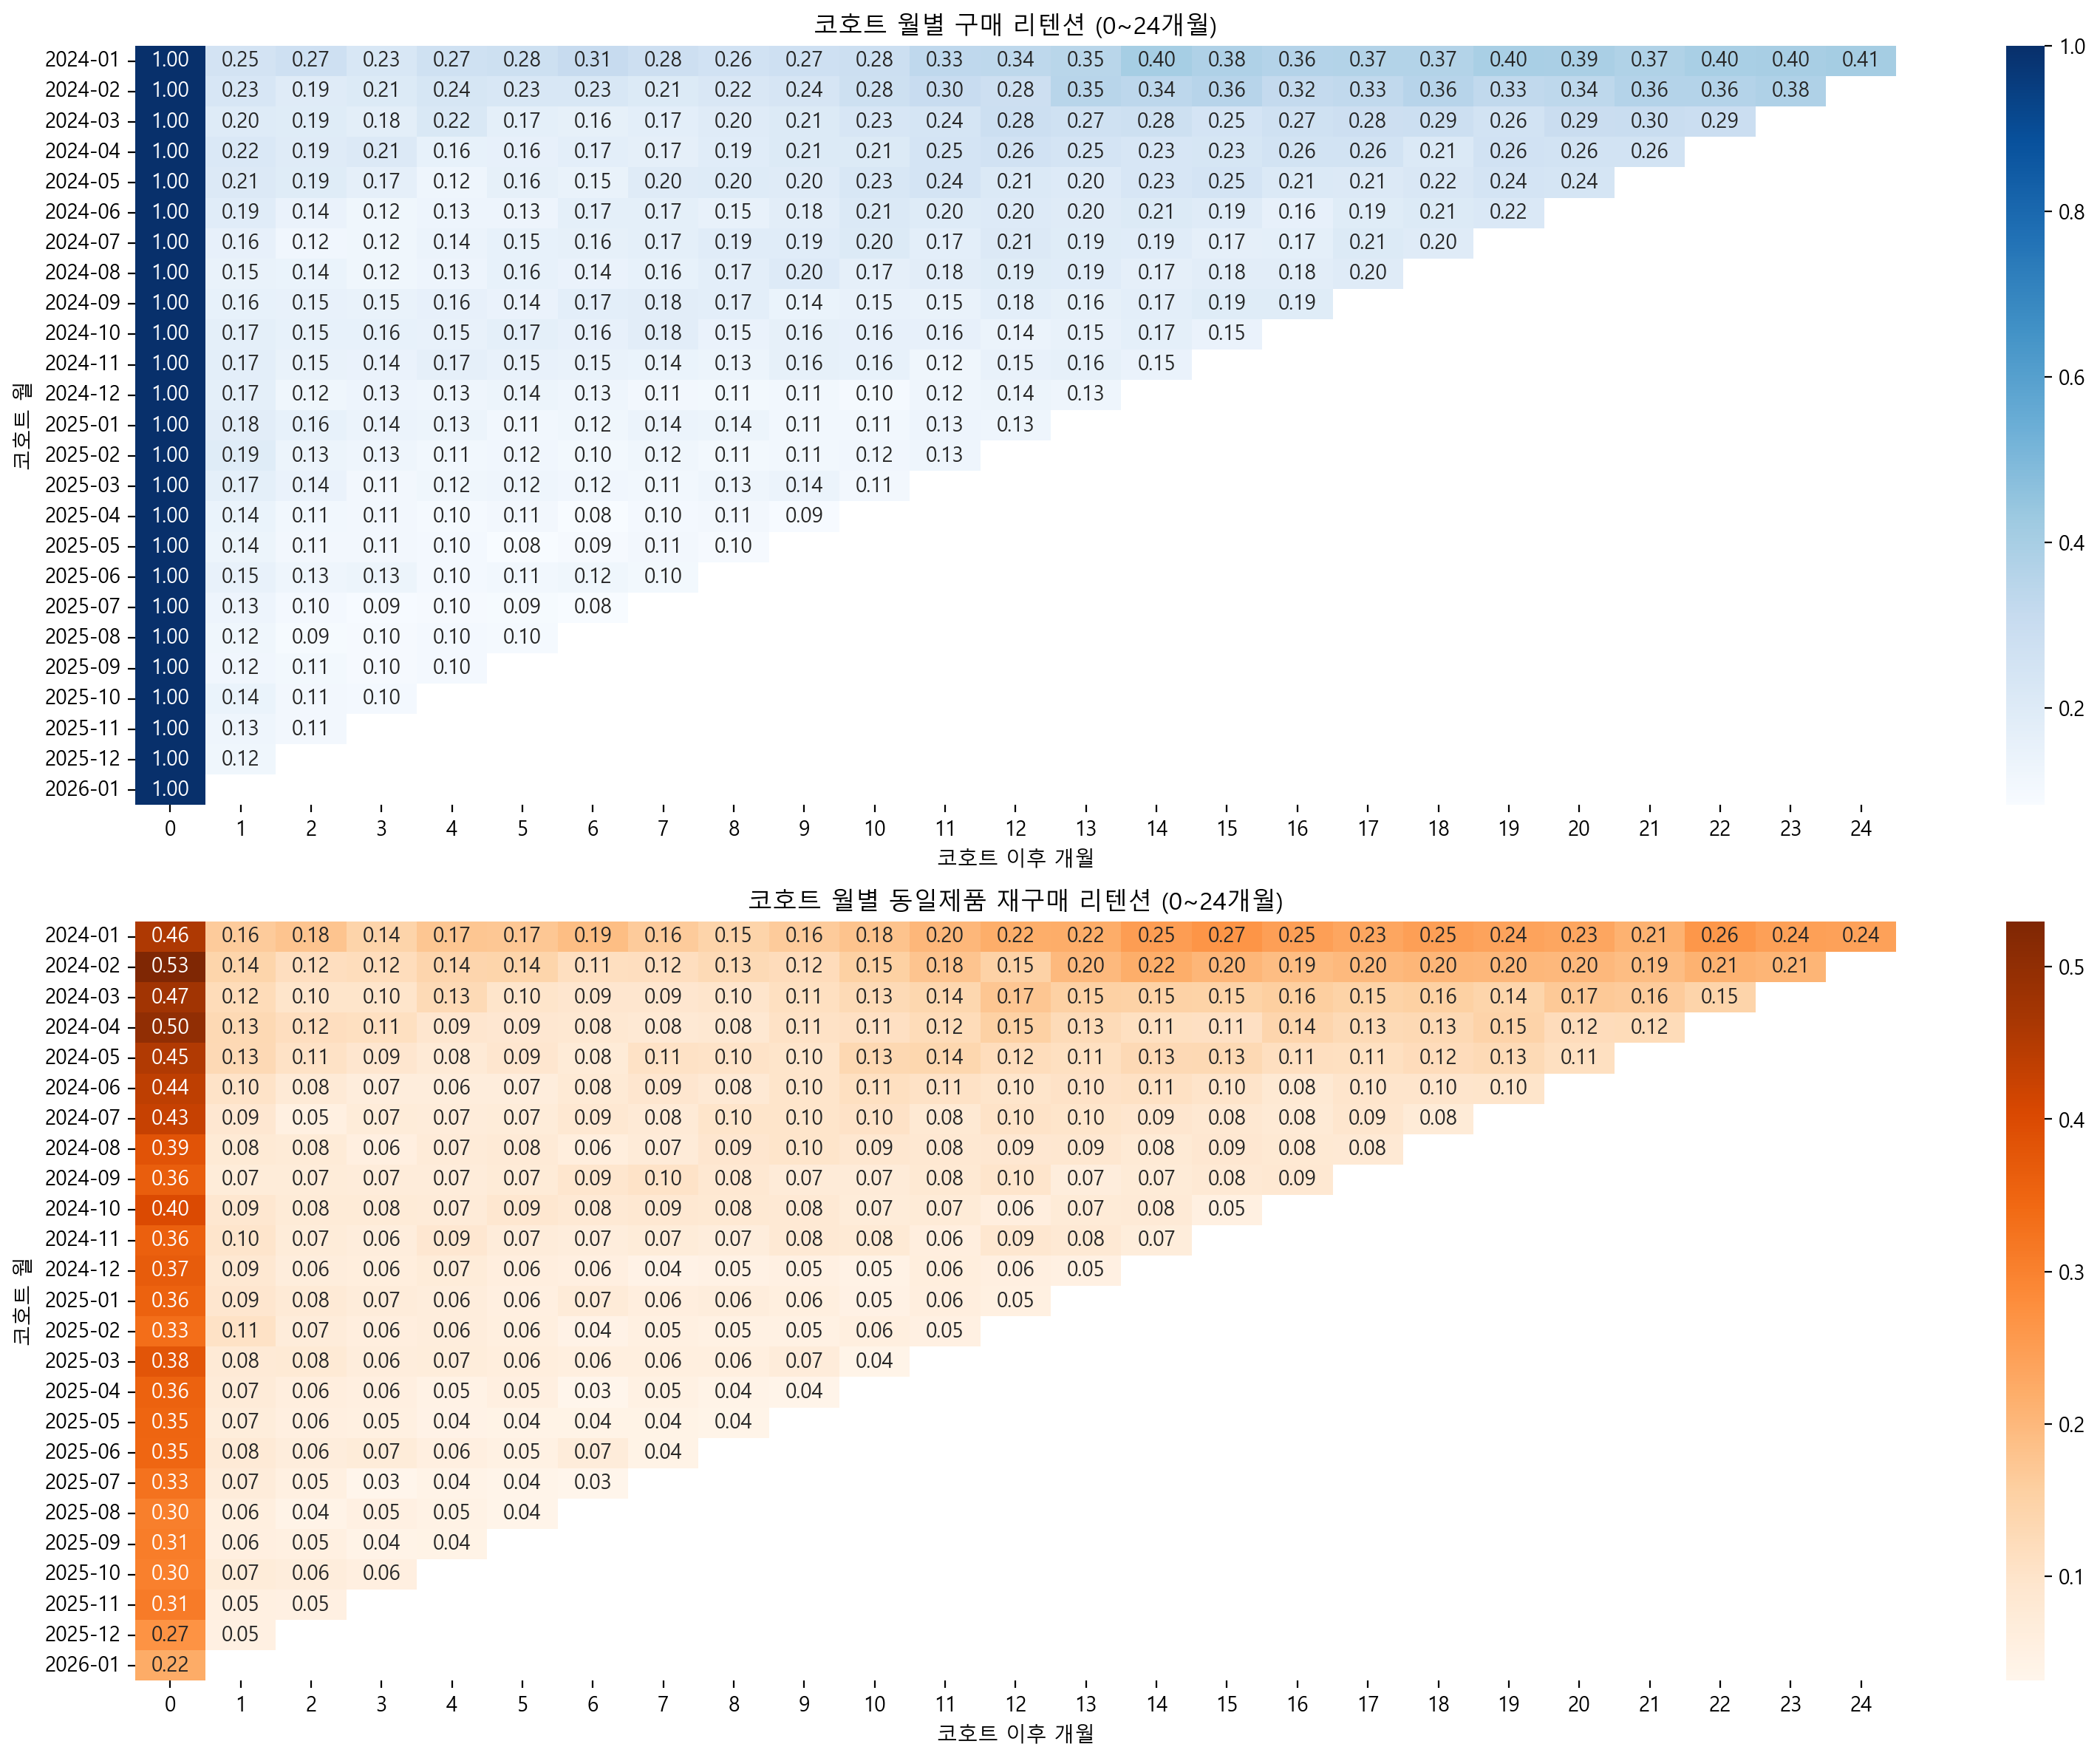

In [37]:
# 21) 코호트 리텐션 EDA (월 코호트)

ts_cutoff = pd.Timestamp('2026-01-31')

co = rv_master.copy()
co['review_date'] = pd.to_datetime(co['review_date'], errors='coerce')
co = co.dropna(subset=['review_date', 'user_id'])
co = co[co['review_date'] <= ts_cutoff].copy()

co['review_month'] = co['review_date'].dt.to_period('M')
first_month = co.groupby('user_id')['review_month'].min().rename('cohort_month')
co = co.merge(first_month, on='user_id', how='left')

co['month_index'] = (co['review_month'] - co['cohort_month']).apply(lambda x: x.n)
co = co[co['month_index'] >= 0]

# 코호트 크기
cohort_size = co.groupby('cohort_month')['user_id'].nunique().rename('cohort_users')

# 월별 활성 사용자 리텐션
ret = (co.groupby(['cohort_month','month_index'])['user_id']
       .nunique()
       .rename('active_users')
       .reset_index()
       .merge(cohort_size.reset_index(), on='cohort_month', how='left'))
ret['retention_rate'] = ret['active_users'] / ret['cohort_users']

# 재구매 리텐션(해당 월에 is_reorder=True 사용자 비율)
re_ret = (co[co['is_reorder'] == True]
      .groupby(['cohort_month','month_index'])['user_id']
      .nunique()
      .rename('reorder_users')
      .reset_index()
      .merge(cohort_size.reset_index(), on='cohort_month', how='right'))
re_ret['reorder_users'] = re_ret['reorder_users'].fillna(0)
re_ret['reorder_retention'] = re_ret['reorder_users'] / re_ret['cohort_users']

# 표시용 (0~24개월)
max_m = 24
ret_pv = (ret[ret['month_index'].between(0, max_m)]
          .pivot(index='cohort_month', columns='month_index', values='retention_rate')
          .sort_index())
re_pv = (re_ret[re_ret['month_index'].between(0, max_m)]
         .pivot(index='cohort_month', columns='month_index', values='reorder_retention')
         .sort_index())

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
sns.heatmap(ret_pv, annot=True, fmt='.2f', cmap='Blues', ax=axes[0])
axes[0].set_title('코호트 월별 구매 리텐션 (0~24개월)')
axes[0].set_xlabel('코호트 이후 개월')
axes[0].set_ylabel('코호트 월')

sns.heatmap(re_pv, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1])
axes[1].set_title('코호트 월별 동일제품 재구매 리텐션 (0~24개월)')
axes[1].set_xlabel('코호트 이후 개월')
axes[1].set_ylabel('코호트 월')

plt.tight_layout()
plt.show()

### 다이소몰 오픈 직후 가입한 코호트의 충성도가 상당히 높다

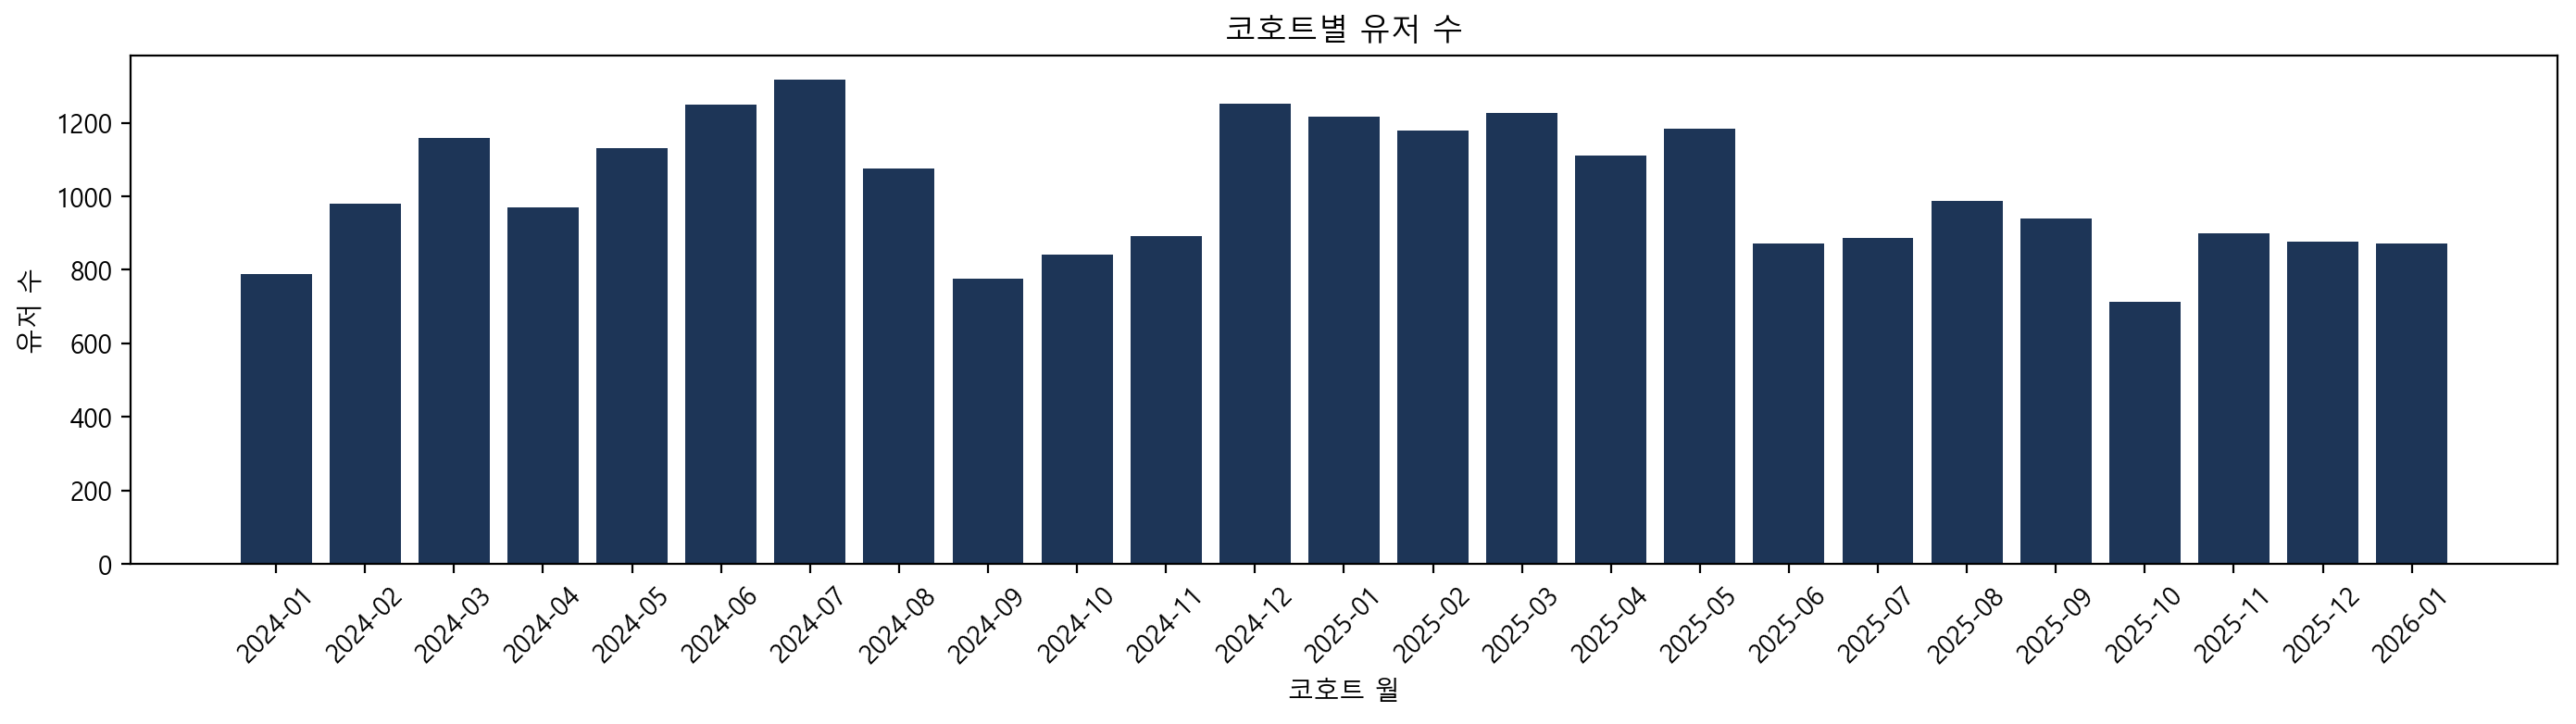

In [38]:
# 코호트별 유저 수 테이블
cohort_size_tbl = cohort_size.reset_index().sort_values('cohort_month')
cohort_size_tbl['cohort_month'] = cohort_size_tbl['cohort_month'].astype(str)

# 코호트별 유저 수 막대그래프
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(cohort_size_tbl['cohort_month'], cohort_size_tbl['cohort_users'], color='#1d3557')
ax.set_title('코호트별 유저 수')
ax.set_xlabel('코호트 월')
ax.set_ylabel('유저 수')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


In [39]:
# 2024-01 코호트 유저의 마지막 활동(라스트) 확인
target_cohort = pd.Period('2024-01', freq='M')

co_jan = co[co['cohort_month'] == target_cohort].copy()

last_user = (co_jan.sort_values(['user_id', 'review_date'])
    .groupby('user_id')
    .agg(
        cohort_month=('cohort_month', 'first'),
        first_review_date=('review_date', 'min'),
        last_review_date=('review_date', 'max'),
        last_month_index=('month_index', 'max'),
        total_reviews=('review_id', 'count')
    )
    .reset_index())

# 라스트 기준 상위 확인
# 많은 순 정렬
display(
    last_user.sort_values(['total_reviews', 'last_review_date'], ascending=[False, False]).head(10)
)

# 요약
print('2024-01 코호트 유저 수:', last_user['user_id'].nunique())
print('해당 코호트 마지막 리뷰일(최댓값):', last_user['last_review_date'].max())
print('해당 코호트 마지막 month_index(최댓값):', last_user['last_month_index'].max())


,user_id,cohort_month,first_review_date,last_review_date,last_month_index,total_reviews
212,213,2024-01,2024-01-12,2026-01-31,24,2058
79,80,2024-01,2024-01-05,2026-01-30,24,931
55,56,2024-01,2024-01-04,2025-12-24,23,762
104,105,2024-01,2024-01-06,2026-01-30,24,682
257,258,2024-01,2024-01-15,2026-01-30,24,594
343,344,2024-01,2024-01-18,2026-01-28,24,560
227,228,2024-01,2024-01-13,2026-01-29,24,543
143,144,2024-01,2024-01-09,2026-01-31,24,494
601,602,2024-01,2024-01-26,2026-01-28,24,484
211,212,2024-01,2024-01-12,2026-01-30,24,466


2024-01 코호트 유저 수: 788
해당 코호트 마지막 리뷰일(최댓값): 2026-01-31 00:00:00
해당 코호트 마지막 month_index(최댓값): 24


### 24년 1월 코호트 유저가 많은 이유를 알아냄
d01******** 와 같이 전화번호 가입 고객이거나 <br>
kim******** 와 같이 김씨 성을 가진 고객의 경우인것으로 판별..

,ym,review_cnt,one_star_rate,avg_rating
1,2024-02,3389,0.004426,4.831219
2,2024-03,4855,0.005973,4.811329
3,2024-04,4874,0.011695,4.767952
4,2024-05,6478,0.009262,4.757487
5,2024-06,7993,0.008007,4.769423
6,2024-07,9508,0.010202,4.763357
7,2024-08,8552,0.008536,4.775959
8,2024-09,7381,0.007452,4.778756
9,2024-10,8049,0.011678,4.740837
10,2024-11,9540,0.020440,4.723480


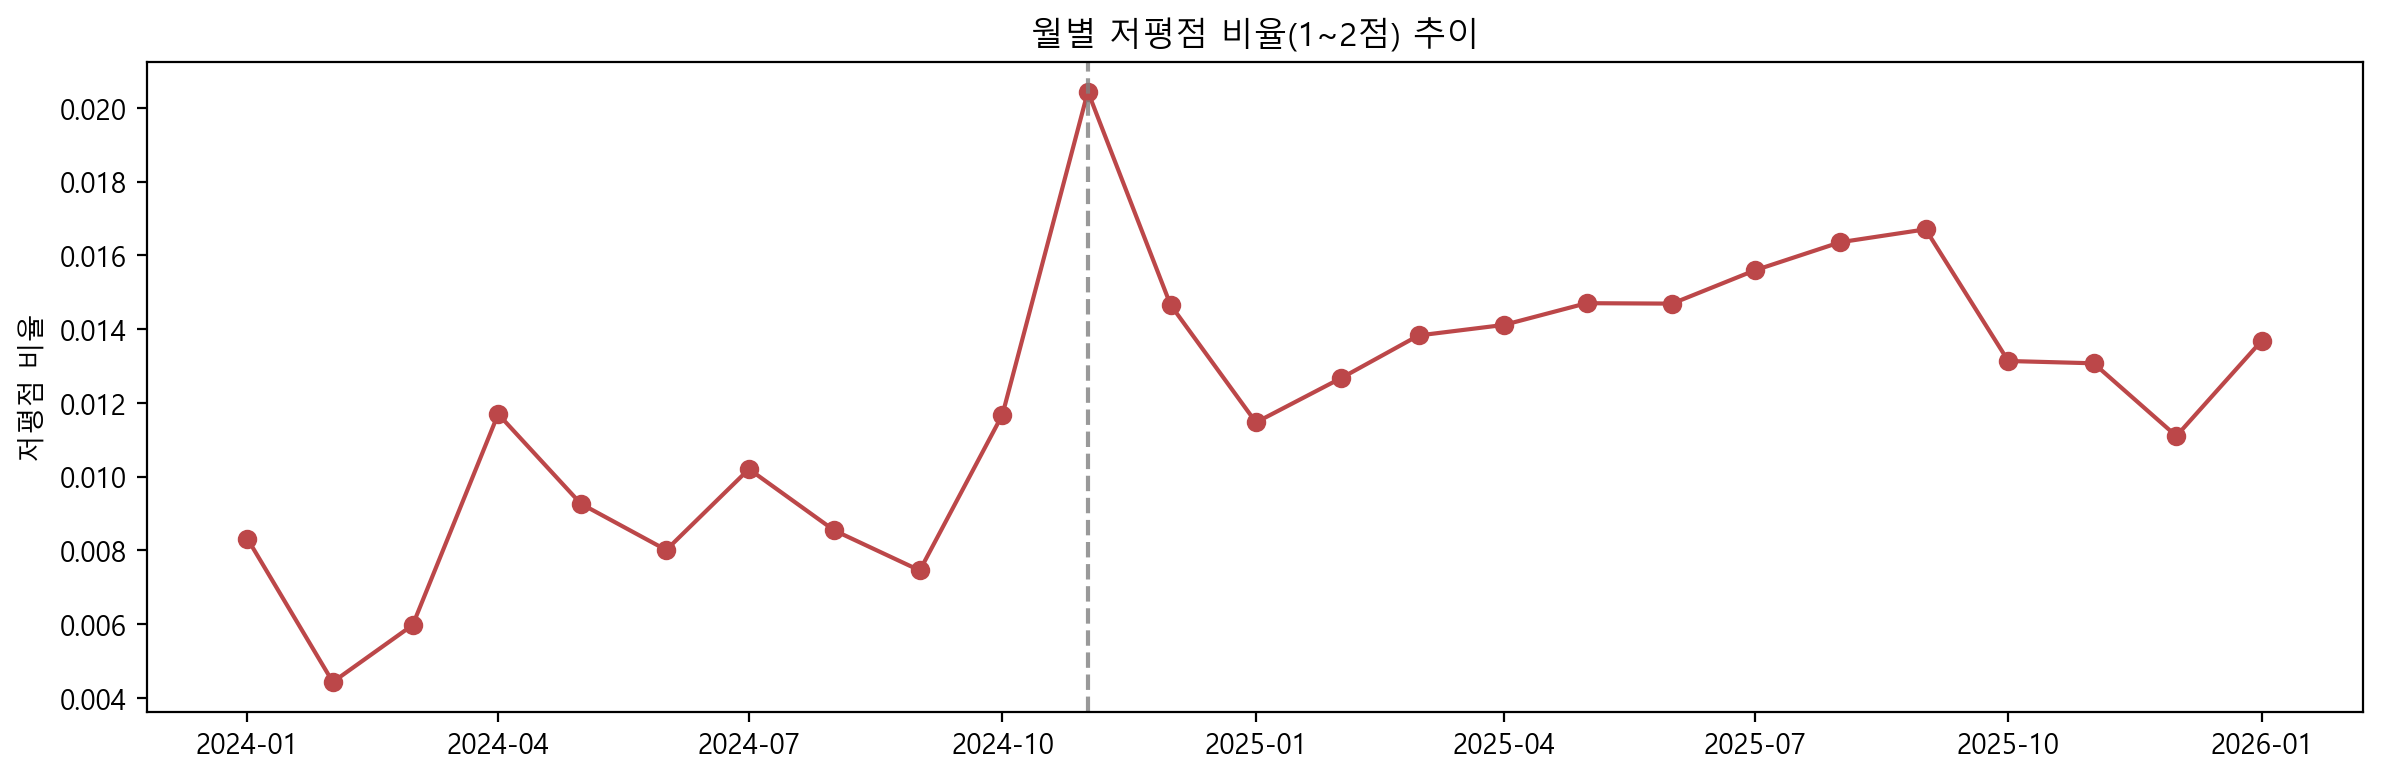

,category_2,base_cnt,base_one_star,nov_cnt,nov_one_star,delta,impact_proxy
10,치크/하이라이터,677,0.011817,423,0.130024,0.118207,50.001477
5,립메이크업,3482,0.015508,781,0.043534,0.028026,21.887995
0,기초스킨케어,16248,0.004554,4465,0.008959,0.004404,19.664574
8,아이메이크업,2106,0.020418,1005,0.026866,0.006448,6.480057
7,베이스메이크업,2345,0.014925,839,0.022646,0.007721,6.477612
3,남성용면도기,180,0.022222,77,0.038961,0.016739,1.288889
12,클렌징/필링,2400,0.010000,551,0.010889,0.000889,0.490000
11,클렌징/쉐이빙,54,0.000000,10,0.000000,0.000000,0.000000
1,남성메이크업,6,0.000000,4,0.000000,0.000000,0.000000
2,남성스킨케어,115,0.026087,45,0.022222,-0.003865,-0.173913


In [40]:
# 23) 품질 이슈 전이 증거 (2024-11 쇼크)
shock = reviews.copy()
shock['review_date'] = pd.to_datetime(shock['review_date'], errors='coerce')
shock = shock.dropna(subset=['review_date'])
shock = shock[shock['review_date'] <= pd.Timestamp('2026-01-31')].copy()
shock = shock.merge(products[['product_code','category_2']], on='product_code', how='left')
shock['ym'] = shock['review_date'].dt.to_period('M')

mon = (shock.groupby('ym')
    .agg(review_cnt=('review_id','count'),
         one_star_rate=('rating', lambda s: (s <= 2).mean()),
         avg_rating=('rating','mean'))
    .reset_index())

display(mon.tail(24))

fig, ax = plt.subplots(1, 1, figsize=(12, 4))
ax.plot(mon['ym'].dt.to_timestamp(), mon['one_star_rate'], marker='o', color='#bc4749')
ax.axvline(pd.Timestamp('2024-11-01'), linestyle='--', color='gray', alpha=0.8)
ax.set_title('월별 저평점 비율(1~2점) 추이')
ax.set_xlabel('')
ax.set_ylabel('저평점 비율')
plt.tight_layout()
plt.show()

base_period = shock[(shock['ym'] >= pd.Period('2024-07','M')) & (shock['ym'] <= pd.Period('2024-10','M'))]
nov_period  = shock[shock['ym'] == pd.Period('2024-11','M')]

b = (base_period.groupby('category_2')
     .agg(base_cnt=('review_id','count'),
          base_one_star=('rating', lambda s: (s <= 2).mean()))
     .reset_index())

n = (nov_period.groupby('category_2')
     .agg(nov_cnt=('review_id','count'),
          nov_one_star=('rating', lambda s: (s <= 2).mean()))
     .reset_index())

impact = b.merge(n, on='category_2', how='outer').fillna(0)
impact['delta'] = impact['nov_one_star'] - impact['base_one_star']
impact['impact_proxy'] = impact['delta'] * impact['nov_cnt']

display(impact.sort_values('impact_proxy', ascending=False).head(12))


### 품질이슈가 발생한 2024년 11월 실제 2점이하 리뷰 수가 압도적이다

=====================================================================================================
### 연착륙 (야매, 차후 영호님 분석 참고예정)

,지표,값
0,히트 후보 SKU 수,229.0000
1,연착륙 SKU 수,21.0000
2,연착륙 비중,0.0917


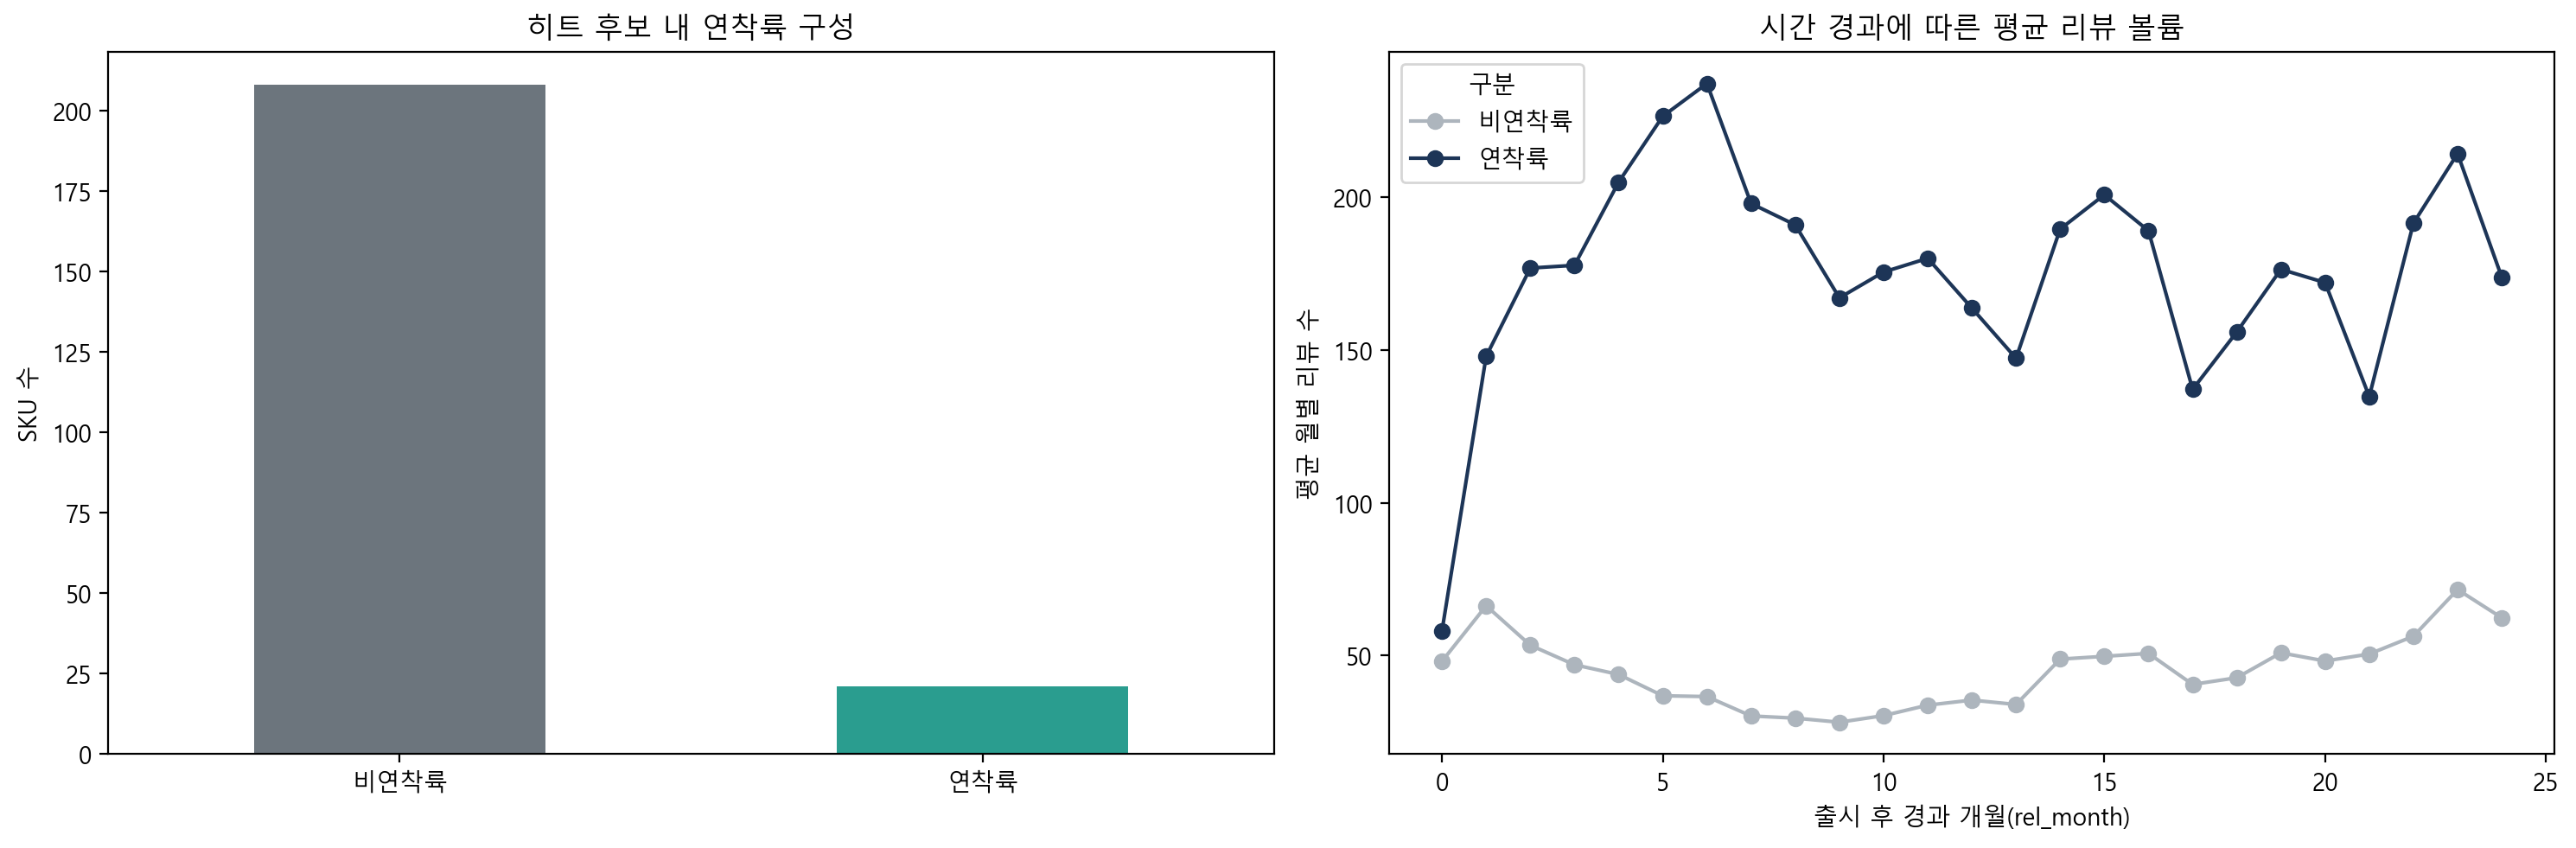

연착륙 비중(히트 후보 기준): 9.17 %


In [41]:
# 17) 연착륙 법칙 검증 (비감성 행동지표 기준)

sl_all = rv_master[['product_code','review_id','review_date','rating','is_reorder','price','category_1','category_2','brand_name']].copy()
first_date = sl_all.groupby('product_code')['review_date'].min().rename('first_date').reset_index()
sl_all = sl_all.merge(first_date, on='product_code', how='left')
sl_all['rel_month'] = ((sl_all['review_date'].dt.year * 12 + sl_all['review_date'].dt.month)
    - (sl_all['first_date'].dt.year * 12 + sl_all['first_date'].dt.month))

monthly_all = (sl_all.groupby(['product_code','rel_month'])
    .agg(review_cnt=('review_id','count'),
         reorder_rate=('is_reorder','mean'),
         avg_rating=('rating','mean'))
    .reset_index())

def _wmean(g, col, a, b):
    t = g[(g['rel_month'] >= a) & (g['rel_month'] <= b)]
    return t[col].mean() if len(t) > 0 else np.nan

def _wsum(g, col, a, b):
    t = g[(g['rel_month'] >= a) & (g['rel_month'] <= b)]
    return t[col].sum() if len(t) > 0 else np.nan

rows = []
for sku, g in monthly_all.groupby('product_code'):
    rows.append({
        'product_code': sku,
        'm0_2_sum': _wsum(g, 'review_cnt', 0, 2),
        'm0_2_avg': _wmean(g, 'review_cnt', 0, 2),
        'm6_8_avg': _wmean(g, 'review_cnt', 6, 8),
        'r0_2': _wmean(g, 'reorder_rate', 0, 2),
        'r6_11': _wmean(g, 'reorder_rate', 6, 11),
        'rating_0_2': _wmean(g, 'avg_rating', 0, 2),
        'rating_6_11': _wmean(g, 'avg_rating', 6, 11),
        'months_obs': g['rel_month'].nunique()
    })

landing_feat = pd.DataFrame(rows).merge(
    sl_all[['product_code','price','category_1','category_2','brand_name','first_date']].drop_duplicates('product_code'),
    on='product_code', how='left'
)

mature_cutoff = pd.Timestamp('2025-07-31')
mature_feat = landing_feat[landing_feat['first_date'] <= mature_cutoff].copy()

hit_threshold = mature_feat['m0_2_sum'].quantile(0.70)
hit_candidates = mature_feat[mature_feat['m0_2_sum'] >= hit_threshold].copy()

# 운영 정의: 후반 볼륨 유지 + 후반 재구매율 기준
hit_candidates['is_landing'] = ((hit_candidates['m6_8_avg'] >= hit_candidates['m0_2_avg'] * 0.25) &
                              (hit_candidates['r6_11'] >= 0.40))

landing_group = hit_candidates[hit_candidates['is_landing']].copy()
non_landing_group = hit_candidates[~hit_candidates['is_landing']].copy()

landing_summary = pd.DataFrame({
    '지표': ['히트 후보 SKU 수', '연착륙 SKU 수', '연착륙 비중'],
    '값': [
        len(hit_candidates),
        int(hit_candidates['is_landing'].sum()),
        round(hit_candidates['is_landing'].mean(), 4)
    ]
})
display(landing_summary)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
pd.Series({'비연착륙': len(non_landing_group), '연착륙': len(landing_group)}).plot(
    kind='bar', ax=axes[0], color=['#6c757d','#2a9d8f']
)
axes[0].set_title('히트 후보 내 연착륙 구성')
axes[0].set_xlabel('')
axes[0].set_ylabel('SKU 수')
axes[0].tick_params(axis='x', rotation=0)

trend_df = (monthly_all[monthly_all['product_code'].isin(hit_candidates['product_code'])]
    .merge(hit_candidates[['product_code','is_landing']], on='product_code', how='left')
    .groupby(['is_landing','rel_month'])['review_cnt']
    .mean()
    .reset_index())
trend_df['구분'] = trend_df['is_landing'].map({False:'비연착륙', True:'연착륙'})
for key, color in [(False, '#adb5bd'), (True, '#1d3557')]:
    t = trend_df[trend_df['is_landing'] == key].sort_values('rel_month')
    axes[1].plot(t['rel_month'], t['review_cnt'], marker='o', label=t['구분'].iloc[0], color=color)
axes[1].set_title('시간 경과에 따른 평균 리뷰 볼륨')
axes[1].set_xlabel('출시 후 경과 개월(rel_month)')
axes[1].set_ylabel('평균 월별 리뷰 수')
axes[1].legend(title='구분')

plt.tight_layout()
plt.show()

print('연착륙 비중(히트 후보 기준):', round(hit_candidates['is_landing'].mean() * 100, 2), '%')

,지표,연착륙,비연착륙
0,평균 가격,3976.190476,3891.826923
1,평균 후반 재구매율,0.470412,0.234656
2,평균 후반 평점,4.797727,4.683038


,category_1,비중
0,스킨케어,1.0


,price_tier,비중
0,Premium(5000),0.571429
1,Standard(3000~4990),0.333333
2,Easy(<=2990),0.095238


연착륙 SKU 비중(히트 후보 내): 0.0917
리뷰 비중(히트 후보 내): 0.3736
매출 프록시 비중(가격*리뷰수, 히트 후보 내): 0.3774


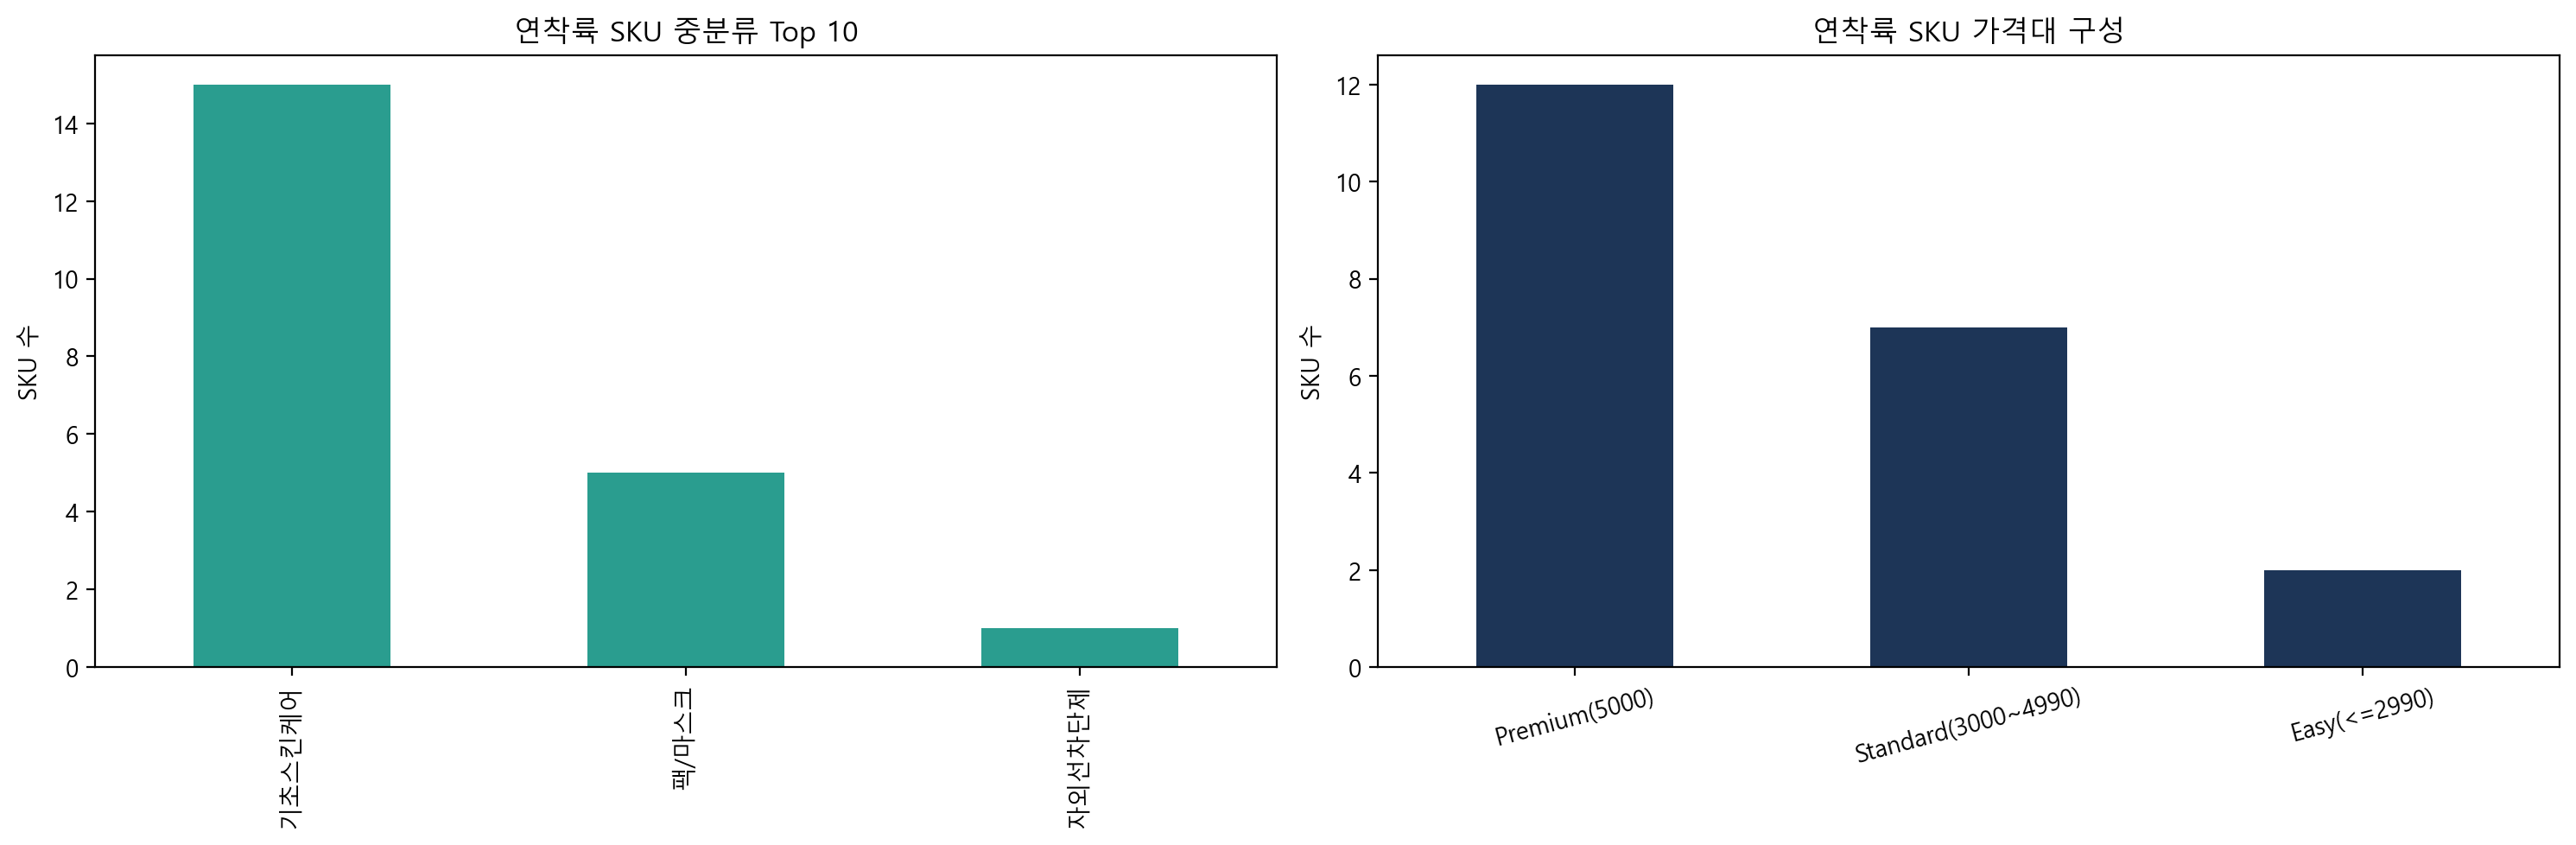

In [42]:
# 18) 연착륙 제품 특성 + 매출 집중도(프록시)
if len(hit_candidates) == 0:
    print('히트 후보 SKU가 없어 다음 분석을 생략합니다.')
else:
    # 가격대 구간
    def _tier(p):
        if pd.isna(p):
            return 'Unknown'
        if p >= 5000:
            return 'Premium(5000)'
        if p >= 3000:
            return 'Standard(3000~4990)'
        return 'Easy(<=2990)'

    hit_candidates = hit_candidates.copy()
    hit_candidates['price_tier'] = hit_candidates['price'].apply(_tier)

    landing_group = hit_candidates[hit_candidates['is_landing']].copy()
    non_landing_group = hit_candidates[~hit_candidates['is_landing']].copy()

    cmp_tbl = pd.DataFrame({
        '지표': ['평균 가격', '평균 후반 재구매율', '평균 후반 평점'],
        '연착륙': [
            landing_group['price'].mean(),
            landing_group['r6_11'].mean(),
            landing_group['rating_6_11'].mean()
        ],
        '비연착륙': [
            non_landing_group['price'].mean(),
            non_landing_group['r6_11'].mean(),
            non_landing_group['rating_6_11'].mean()
        ]
    })
    display(cmp_tbl)

    cat_share = (landing_group['category_1'].value_counts(normalize=True).rename('비중').reset_index()
                 .rename(columns={'index':'category_1'}))
    tier_share = (landing_group['price_tier'].value_counts(normalize=True).rename('비중').reset_index()
                  .rename(columns={'index':'price_tier'}))
    display(cat_share)
    display(tier_share)

    sku_review = sl_all.groupby('product_code')['review_id'].count().rename('tot_reviews').reset_index()
    cand_proxy = hit_candidates[['product_code','price']].merge(sku_review, on='product_code', how='left')
    land_proxy = landing_group[['product_code','price']].merge(sku_review, on='product_code', how='left')
    cand_proxy['proxy_rev'] = cand_proxy['price'] * cand_proxy['tot_reviews']
    land_proxy['proxy_rev'] = land_proxy['price'] * land_proxy['tot_reviews']

    proxy_share = land_proxy['proxy_rev'].sum() / cand_proxy['proxy_rev'].sum() if len(cand_proxy) > 0 else np.nan
    review_share = land_proxy['tot_reviews'].sum() / cand_proxy['tot_reviews'].sum() if len(cand_proxy) > 0 else np.nan

    print('연착륙 SKU 비중(히트 후보 내):', round(len(landing_group) / len(hit_candidates), 4))
    print('리뷰 비중(히트 후보 내):', round(review_share, 4))
    print('매출 프록시 비중(가격*리뷰수, 히트 후보 내):', round(proxy_share, 4))

# category_1 그래프 제거, category_2로 대체
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

landing_group['category_2'].value_counts().head(10).plot(
    kind='bar', ax=axes[0], color='#2a9d8f'
)
axes[0].set_title('연착륙 SKU 중분류 Top 10')
axes[0].set_xlabel('')
axes[0].set_ylabel('SKU 수')

landing_group['price_tier'].value_counts().plot(
    kind='bar', ax=axes[1], color='#1d3557'
)
axes[1].set_title('연착륙 SKU 가격대 구성')
axes[1].set_xlabel('')
axes[1].set_ylabel('SKU 수')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [44]:
# 연착륙 사전 검증용

ts_cutoff = pd.Timestamp('2026-01-31')

dict_path = Path('G:/Final_proj/daiso/archive/연착륙 사전.txt')
txt = dict_path.read_text(encoding='utf-8-sig')

patterns = regex.findall(r"r'([^']+)'", txt)
patterns = [p.replace('\\b', '') for p in patterns]
patterns = [p for p in patterns if '재구매(?:할|했|함|중|합니다|예정|각|각임)?' not in p]

tmp = reviews[['product_code','text','review_date']].copy()
tmp['review_date'] = pd.to_datetime(tmp['review_date'], errors='coerce')
tmp = tmp.dropna(subset=['review_date'])
tmp = tmp[tmp['review_date'] <= ts_cutoff].copy()
tmp['text'] = tmp['text'].fillna('')

hit_cols = []
for i, ptn in enumerate(patterns):
    col = f'h{i}'
    hit_cols.append(col)
    try:
        tmp[col] = tmp['text'].str.contains(regex.compile(ptn), regex=True)
    except Exception:
        tmp[col] = False

tmp['landing_dict_hit'] = tmp[hit_cols].any(axis=1)
prod_hit = tmp.groupby('product_code')['landing_dict_hit'].mean().rename('landing_dict_hit_rate').reset_index()

dict_cmp = (hit_candidates[['product_code','is_landing']]
    .merge(prod_hit, on='product_code', how='left')
    .fillna({'landing_dict_hit_rate': 0})
    .groupby('is_landing')['landing_dict_hit_rate']
    .agg(['count','mean','median'])
    .rename(index={False: '비연착륙', True: '연착륙'}))
display(dict_cmp)

# 유의제품 필터 기대효익: 상위 위험군 커버리지
rb = risk_base.copy()
rb['neg_review_cnt'] = rb['review_cnt'] * rb['one_star_rate']
rb['issue_proxy'] = rb['neg_review_cnt'] * rb['price'].fillna(rb['price'].median())

rows = []
for q in [0.90, 0.85, 0.80]:
    cut = rb['risk_score'].quantile(q)
    w = rb[rb['risk_score'] >= cut]
    rows.append({
        'watch_threshold': f'top {int((1-q)*100)}%',
        'sku_n': len(w),
        'neg_review_share': w['neg_review_cnt'].sum() / rb['neg_review_cnt'].sum(),
        'issue_proxy_share': w['issue_proxy'].sum() / rb['issue_proxy'].sum(),
        'watch_avg_one_star': w['one_star_rate'].mean(),
        'all_avg_one_star': rb['one_star_rate'].mean()
    })

benefit_tbl = pd.DataFrame(rows)
display(benefit_tbl)



,count,mean,median
is_landing,,,
비연착륙,208,0.050856,0.052662
연착륙,21,0.085305,0.082533


,watch_threshold,sku_n,neg_review_share,issue_proxy_share,watch_avg_one_star,all_avg_one_star
0,top 9%,69,0.177009,0.165968,0.053025,0.018201
1,top 15%,103,0.232452,0.223247,0.049664,0.018201
2,top 19%,137,0.283571,0.266764,0.044832,0.018201


- 리스크 상위 10% SKU가 전체 이슈 프록시의 **16.5%** 를 커버
- 리스크 상위 20% SKU가 전체 이슈 프록시의 **26.7%** 를 커버

==================================================================================================================

### 머신러닝 스토리텔링 흐름
1. 연착륙 제품 특성 확인
2. 연착륙 조기예측 모델 구축
3. 리스크 사전경보 모델 구축
4. SKU 1개 기준 창출(연착륙) vs 방어(리스크) 효과 비교


공통 월패널(프로모션 기간, 성분 피처)을 먼저 구성합니다.

이후 연착륙 조기예측과 리스크 사전경보를 같은 입력 체계로 비교합니다.


In [45]:
# 41) 공통 준비: 월패널 + 성분피처 + 프로모션기간 변수
from lightgbm import LGBMClassifier, LGBMRegressor
from xgboost import XGBClassifier, XGBRegressor
from catboost import CatBoostClassifier

from sklearn.metrics import average_precision_score, roc_auc_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

# 기본 체크
need = ['products', 'reviews', 'promotions', 'ingredients']
miss = [v for v in need if v not in globals()]
if miss:
    raise ValueError(f'먼저 로드 필요한 변수: {miss}')

# 컷오프 날짜
ts_cutoff = pd.Timestamp('2026-01-31')

# 리뷰 베이스
rv = reviews.copy()
rv['review_date'] = pd.to_datetime(rv['review_date'], errors='coerce')
rv = rv.dropna(subset=['review_date'])
rv = rv[rv['review_date'] <= ts_cutoff].copy()

# 프로모션 기간 변수(기준)
promo_cal = promotions[['brand_name', 'start_date', 'end_date']].copy()
promo_cal['start_date'] = pd.to_datetime(promo_cal['start_date'], errors='coerce')
promo_cal['end_date'] = pd.to_datetime(promo_cal['end_date'], errors='coerce')
promo_cal['end_date'] = promo_cal['end_date'].fillna(promo_cal['start_date'] + pd.Timedelta(days=13))
promo_cal = promo_cal.dropna(subset=['brand_name', 'start_date', 'end_date'])

meta = products[['product_code','brand_name','category_1','category_2','price']].drop_duplicates('product_code')
rv = rv.merge(meta, on='product_code', how='left')

rv['is_promo_period'] = False
for b, g in promo_cal.groupby('brand_name'):
    m = rv['brand_name'].eq(b)
    if not m.any():
        continue
    d = rv.loc[m, 'review_date']
    flag = pd.Series(False, index=d.index)
    for s, e in zip(g['start_date'], g['end_date']):
        flag |= d.between(s, e, inclusive='both')
    rv.loc[m, 'is_promo_period'] = flag

# 성분 피처
ing = ingredients.copy()
if pd.api.types.is_numeric_dtype(ing['is_allergic']):
    ing['is_allergic_bin'] = ing['is_allergic'].fillna(0).astype(float).gt(0)
else:
    ing['is_allergic_bin'] = ing['is_allergic'].astype(str).str.lower().isin(['1','true','y','yes'])

ing_feat = (ing.groupby('product_code')
    .agg(ingredient_count=('ingredient_id','count'),
         is_allergic_count=('is_allergic_bin','sum'))
    .reset_index())

# SKU-월 패널
rv['ym'] = rv['review_date'].dt.to_period('M')
sku_mon = (rv.groupby(['product_code','ym'])
    .agg(review_cnt=('review_id','count'),
         avg_rating=('rating','mean'),
         one_star_rate=('rating', lambda s: (s <= 2).mean()),
         reorder_rate=('is_reorder','mean'),
         rating_std=('rating','std'),
         review_len=('review_length','mean'),
         image_ratio=('image_count', lambda s: (s > 0).mean()),
         promo_share=('is_promo_period','mean'),
         brand_name=('brand_name','first'),
         category_1=('category_1','first'),
         category_2=('category_2','first'),
         price=('price','first'))
    .reset_index())

sku_mon['rating_std'] = sku_mon['rating_std'].fillna(0)
sku_mon = sku_mon.merge(ing_feat, on='product_code', how='left')
sku_mon[['ingredient_count','is_allergic_count']] = sku_mon[['ingredient_count','is_allergic_count']].fillna(0)

# 정렬
sku_mon = sku_mon.sort_values(['product_code','ym']).reset_index(drop=True)

print('sku_mon shape:', sku_mon.shape)
display(sku_mon.head())

sku_mon shape: (12879, 16)


,product_code,ym,review_cnt,avg_rating,one_star_rate,reorder_rate,rating_std,review_len,image_ratio,promo_share,brand_name,category_1,category_2,price,ingredient_count,is_allergic_count
0,31386,2024-01,2,4.500,0.0,0.00,0.707107,29.00,1.00,0.0,뉴트로지나,스킨케어,립케어,3000.0,8.0,0.0
1,31386,2024-02,2,5.000,0.0,0.50,0.000000,19.50,0.50,0.0,뉴트로지나,스킨케어,립케어,3000.0,8.0,0.0
2,31386,2024-03,8,4.875,0.0,0.25,0.353553,21.00,0.25,0.0,뉴트로지나,스킨케어,립케어,3000.0,8.0,0.0
3,31386,2024-04,5,5.000,0.0,0.20,0.000000,20.40,0.40,0.0,뉴트로지나,스킨케어,립케어,3000.0,8.0,0.0
4,31386,2024-05,4,5.000,0.0,0.25,0.000000,25.25,0.75,0.0,뉴트로지나,스킨케어,립케어,3000.0,8.0,0.0


==================================================================================================================

### 1) 연착륙 SKU 조기예측 모델 선택 근거
- 목표: 출시 초기(0~2개월) 신호로 연착륙 가능 SKU를 선별
- 후보 모델: LightGBM, XGBoost
- 선택 이유:
  - 데이터에서 비선형 관계를 잘 학습
  - 표본이 크지 않아도 안정적으로 동작
  - 클래스 불균형 대응(`scale_pos_weight`)이 쉬움
- 평가 지표:
  - `PR-AUC`: 양성 희소 상황에 적합
  - `Recall@20`: 상위 후보군 포착력 확인
- 선택 기준: `PR-AUC` 우선, 동률이면 `Recall@20` 높은 모델 선택


In [46]:
# 42) 1) 연착륙 SKU 조기예측 (LightGBM / XGBoost, PR-AUC + Recall@TopK)

# 라벨 만들기 (#17 로직)
sl = rv[['product_code','review_id','review_date','rating','is_reorder','price','category_1','category_2','brand_name']].copy()
first_date = sl.groupby('product_code')['review_date'].min().rename('first_date').reset_index()
sl = sl.merge(first_date, on='product_code', how='left')
sl['rel_month'] = ((sl['review_date'].dt.year * 12 + sl['review_date'].dt.month)
                  - (sl['first_date'].dt.year * 12 + sl['first_date'].dt.month))

mon = (sl.groupby(['product_code','rel_month'])
    .agg(review_cnt=('review_id','count'),
         reorder_rate=('is_reorder','mean'),
         avg_rating=('rating','mean'))
    .reset_index())

def _wmean(g, c, a, b):
    t = g[(g['rel_month'] >= a) & (g['rel_month'] <= b)]
    return t[c].mean() if len(t) > 0 else np.nan

def _wsum(g, c, a, b):
    t = g[(g['rel_month'] >= a) & (g['rel_month'] <= b)]
    return t[c].sum() if len(t) > 0 else np.nan

rows = []
for sku, g in mon.groupby('product_code'):
    fd = first_date.loc[first_date['product_code'].eq(sku), 'first_date'].iloc[0]
    rows.append({
        'product_code': sku,
        'm0_2_sum': _wsum(g,'review_cnt',0,2),
        'm0_2_avg': _wmean(g,'review_cnt',0,2),
        'm6_8_avg': _wmean(g,'review_cnt',6,8),
        'r0_2': _wmean(g,'reorder_rate',0,2),
        'r6_11': _wmean(g,'reorder_rate',6,11),
        'rating_0_2': _wmean(g,'avg_rating',0,2),
        'first_date': fd
    })
landing_feat_ml = pd.DataFrame(rows)

mature_cutoff = pd.Timestamp('2025-07-31')
mature = landing_feat_ml[landing_feat_ml['first_date'] <= mature_cutoff].copy()
hit_th = mature['m0_2_sum'].quantile(0.70)
hit = mature[mature['m0_2_sum'] >= hit_th].copy()
hit['is_landing'] = ((hit['m6_8_avg'] >= hit['m0_2_avg'] * 0.25) & (hit['r6_11'] >= 0.40)).astype(int)

# 초기 3개월 피처
early = sl[(sl['rel_month'] >= 0) & (sl['rel_month'] <= 2)].copy()
early = early.merge(rv[['review_id','promotion_id']], on='review_id', how='left')

early_feat = (early.groupby('product_code')
    .agg(
        m0_2_sum=('review_id','count'),
        r0_2=('is_reorder','mean'),
        rating_0_2=('rating','mean'),
        review_len_0_2=('review_id', lambda x: rv.set_index('review_id').loc[x, 'review_length'].mean()),
        image_ratio_0_2=('review_id', lambda x: (rv.set_index('review_id').loc[x, 'image_count'] > 0).mean()),
        promo_exposure_0_2=('review_id', lambda x: rv.set_index('review_id').loc[x, 'is_promo_period'].mean()),
    )
    .reset_index())

ml1 = (hit[['product_code','is_landing','first_date']]
    .merge(early_feat, on='product_code', how='left')
    .merge(meta, on='product_code', how='left')
    .merge(ing_feat, on='product_code', how='left'))

ml1[['ingredient_count','is_allergic_count']] = ml1[['ingredient_count','is_allergic_count']].fillna(0)

# 시계열 분할
ml1 = ml1.sort_values('first_date').reset_index(drop=True)
split_idx = int(len(ml1) * 0.8)
tr, te = ml1.iloc[:split_idx].copy(), ml1.iloc[split_idx:].copy()

feat_cols = [
    'm0_2_sum','r0_2','rating_0_2','review_len_0_2','image_ratio_0_2','promo_exposure_0_2',
    'price','ingredient_count','is_allergic_count','brand_name','category_1','category_2'
]
X_tr, y_tr = tr[feat_cols].copy(), tr['is_landing'].copy()
X_te, y_te = te[feat_cols].copy(), te['is_landing'].copy()

# 원-핫 인코딩
X_all = pd.concat([X_tr, X_te], axis=0)
X_all = pd.get_dummies(X_all, columns=['brand_name','category_1','category_2'], dummy_na=True)
X_tr_enc = X_all.iloc[:len(X_tr)].copy()
X_te_enc = X_all.iloc[len(X_tr):].copy()

pos = max(1, int(y_tr.sum()))
neg = max(1, int((1 - y_tr).sum()))
spw = neg / pos

def recall_at_k(y_true, y_score, k=20):
    k = min(k, len(y_true))
    order = np.argsort(-y_score)[:k]
    return y_true.iloc[order].sum() / max(1, y_true.sum())

models_1 = {
    'lgbm': LGBMClassifier(
        n_estimators=600, learning_rate=0.03, num_leaves=31,
        subsample=0.9, colsample_bytree=0.9, random_state=42,
        scale_pos_weight=spw
    ),
    'xgb': XGBClassifier(
        n_estimators=600, learning_rate=0.03, max_depth=5,
        subsample=0.9, colsample_bytree=0.9, reg_lambda=1.0,
        random_state=42, eval_metric='logloss',
        scale_pos_weight=spw
    )
}

rows = []
fitted_1 = {}
for n, m in models_1.items():
    m.fit(X_tr_enc, y_tr)
    p = m.predict_proba(X_te_enc)[:,1]
    rows.append({
        'model': n,
        'pr_auc': average_precision_score(y_te, p),
        'roc_auc': roc_auc_score(y_te, p) if y_te.nunique() > 1 else np.nan,
        'recall@10': recall_at_k(y_te.reset_index(drop=True), pd.Series(p), 10),
        'recall@20': recall_at_k(y_te.reset_index(drop=True), pd.Series(p), 20),
        'test_pos_rate': y_te.mean(),
        'n_test': len(y_te)
    })
    fitted_1[n] = m

eval_1 = pd.DataFrame(rows).sort_values('pr_auc', ascending=False)
display(eval_1)

best_1_name = eval_1.iloc[0]['model']
best_1 = fitted_1[best_1_name]
print('best model (landing):', best_1_name)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 19, number of negative: 164
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000045 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 183, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.103825 -> initscore=-2.155427
[LightGBM] [Info] Start training from score -2.155427
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

,model,pr_auc,roc_auc,recall@10,recall@20,test_pos_rate,n_test
0,lgbm,0.274390,0.545455,0.5,0.5,0.043478,46
1,xgb,0.272727,0.511364,0.5,0.5,0.043478,46


best model (landing): lgbm


=============================================================================================================

### 2) 리스크 사전경보 모델 선택 근거
- 목표: 향후 1~3개월 내 저평점 급증/평점 급락 가능 SKU 예측
- 후보 모델: CatBoost, LightGBM
- 선택 이유:
  - CatBoost: 범주형 변수(브랜드/카테고리) 처리에 강함
  - LightGBM: 학습 속도와 성능 균형이 좋은 기준 모델
  - 두 모델 모두 불균형 이진 분류에서 실무 활용성이 높음
- 평가 지표:
  - `PR-AUC`: 희소 이벤트 탐지 성능
  - `Recall_top10pct`: 상위 10% 감시군에서 위험 SKU 회수율
- 선택 기준: `PR-AUC` 우선, 운영 관점에서 `Recall_top10pct` 보조 확인


이 코드의 사전경보 기준은 risk_event 라벨 정의입니다. 핵심은 다음 2가지 중 하나라도 만족하면 “위험(1)”로 본다

기준 1: 향후 1~3개월 평균 저평점률이 전체 분포의 상위 10% 이상<br>
next3_one_star_mean >= p90<br>

기준 2: 향후 1~3개월 평균 평점이 현재 대비 0.15점 이상 하락<br>
(현재 avg_rating - next3_rating_mean) >= 0.15<br>

즉, “앞으로 저평점이 급증하거나 평점이 의미 있게 떨어질 SKU”를 사전경보 대상으로 학습합니다.

모델은 현재/과거 정보(리뷰수, 저평점률, 평점, 재구매율, lag 1~3개월, 프로모션 비중, 성분 리스크, 가격, 카테고리/브랜드)로 위 risk_event를 예측하고, 예측확률이 높은 SKU를 감시 우선순위로 쓰는 구조


### 최종 유의제품 기준: risk_score 상위 10% (quantile=0.90)

In [47]:
# 43) 리스크 사전경보 모델 (유지)

# #56에서 생성한 sku_mon 사용
if 'sku_mon' not in globals():
    raise ValueError('sku_mon not found. Run #56 first.')

risk_df = sku_mon.copy().sort_values(['product_code','ym'])
g = risk_df.groupby('product_code', group_keys=False)

# 미래 라벨(향후 1~3개월)
risk_df['next1_one_star'] = g['one_star_rate'].shift(-1)
risk_df['next2_one_star'] = g['one_star_rate'].shift(-2)
risk_df['next3_one_star'] = g['one_star_rate'].shift(-3)
risk_df['next3_one_star_mean'] = risk_df[['next1_one_star','next2_one_star','next3_one_star']].mean(axis=1)

risk_df['next1_rating'] = g['avg_rating'].shift(-1)
risk_df['next2_rating'] = g['avg_rating'].shift(-2)
risk_df['next3_rating'] = g['avg_rating'].shift(-3)
risk_df['next3_rating_mean'] = risk_df[['next1_rating','next2_rating','next3_rating']].mean(axis=1)

# 이벤트 정의
p90 = risk_df['next3_one_star_mean'].quantile(0.90)
risk_df['risk_event'] = (
    (risk_df['next3_one_star_mean'] >= p90) |
    ((risk_df['avg_rating'] - risk_df['next3_rating_mean']) >= 0.15)
).astype(int)

# 시차 피처
for c in ['review_cnt','one_star_rate','avg_rating','reorder_rate']:
    risk_df[f'{c}_lag1'] = g[c].shift(1)
    risk_df[f'{c}_lag2'] = g[c].shift(2)
    risk_df[f'{c}_lag3'] = g[c].shift(3)

risk_model_df = risk_df.dropna(subset=[
    'risk_event','review_cnt_lag1','review_cnt_lag2','review_cnt_lag3',
    'next3_one_star_mean','next3_rating_mean'
]).copy()

risk_feats = [
    'review_cnt','avg_rating','one_star_rate','reorder_rate','rating_std','review_len','image_ratio','promo_share',
    'ingredient_count','is_allergic_count','price',
    'review_cnt_lag1','review_cnt_lag2','review_cnt_lag3',
    'one_star_rate_lag1','one_star_rate_lag2','one_star_rate_lag3',
    'avg_rating_lag1','avg_rating_lag2','avg_rating_lag3',
    'brand_name','category_1','category_2'
]

risk_model_df = risk_model_df.sort_values('ym')
split_month = risk_model_df['ym'].sort_values().unique()[-4]
tr2 = risk_model_df[risk_model_df['ym'] < split_month].copy()
te2 = risk_model_df[risk_model_df['ym'] >= split_month].copy()

Xtr2 = tr2[risk_feats].copy()
Xte2 = te2[risk_feats].copy()
ytr2 = tr2['risk_event'].copy()
yte2 = te2['risk_event'].copy()

cat_cols = ['brand_name','category_1','category_2']
cat_idx = [Xtr2.columns.get_loc(c) for c in cat_cols]

cb = CatBoostClassifier(
    iterations=700, depth=6, learning_rate=0.03,
    loss_function='Logloss', eval_metric='PRAUC',
    verbose=False, random_seed=42, auto_class_weights='Balanced'
)
cb.fit(Xtr2, ytr2, cat_features=cat_idx)

X2_all = pd.concat([Xtr2, Xte2], axis=0)
X2_all = pd.get_dummies(X2_all, columns=cat_cols, dummy_na=True)
Xtr2_enc = X2_all.iloc[:len(Xtr2)].copy()
Xte2_enc = X2_all.iloc[len(Xtr2):].copy()

pos2 = max(1, int(ytr2.sum())); neg2 = max(1, int((1-ytr2).sum()))
lgb2 = LGBMClassifier(
    n_estimators=700, learning_rate=0.03, num_leaves=31,
    random_state=42, scale_pos_weight=neg2/pos2
)
lgb2.fit(Xtr2_enc, ytr2)

def precision_at_k(y, s, k=100):
    k = min(k, len(y))
    idx = np.argsort(-s)[:k]
    return y.iloc[idx].mean()

def recall_top_decile(y, s):
    k = max(1, int(len(y) * 0.1))
    idx = np.argsort(-s)[:k]
    return y.iloc[idx].sum() / max(1, y.sum())

p_cb = cb.predict_proba(Xte2)[:,1]
p_lg = lgb2.predict_proba(Xte2_enc)[:,1]

eval_risk = pd.DataFrame([
    {
        'model':'catboost',
        'pr_auc': average_precision_score(yte2, p_cb),
        'roc_auc': roc_auc_score(yte2, p_cb) if yte2.nunique() > 1 else np.nan,
        'precision@100': precision_at_k(yte2.reset_index(drop=True), pd.Series(p_cb), 100),
        'recall_top10pct': recall_top_decile(yte2.reset_index(drop=True), pd.Series(p_cb))
    },
    {
        'model':'lgbm',
        'pr_auc': average_precision_score(yte2, p_lg),
        'roc_auc': roc_auc_score(yte2, p_lg) if yte2.nunique() > 1 else np.nan,
        'precision@100': precision_at_k(yte2.reset_index(drop=True), pd.Series(p_lg), 100),
        'recall_top10pct': recall_top_decile(yte2.reset_index(drop=True), pd.Series(p_lg))
    }
]).sort_values('pr_auc', ascending=False)

display(eval_risk)

best_risk_name = eval_risk.iloc[0]['model']
best_risk_model = cb if best_risk_name == 'catboost' else lgb2
print('best model (risk):', best_risk_name)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1957, number of negative: 4543
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4085
[LightGBM] [Info] Number of data points in the train set: 6500, number of used features: 90
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.301077 -> initscore=-0.842175
[LightGBM] [Info] Start training from score -0.842175


,model,pr_auc,roc_auc,precision@100,recall_top10pct
0,catboost,0.599523,0.790284,0.76,0.233454
1,lgbm,0.586788,0.775136,0.79,0.235860


best model (risk): catboost


전체 분류 성능<br>
catboost가 PR-AUC(0.600)와 ROC-AUC(0.790) 모두 lgbm보다 약간 높습니다.<br>
희소 이벤트(리스크 경보)에서는 보통 PR-AUC를 더 중요하게 보므로, 기본 선택은 catboost가 타당합니다.

운영형 Top-K 성능<br>
precision@100은 lgbm(0.79)가 catboost(0.76)보다 약간 높음<br>
recall_top10pct도 lgbm(0.2359)가 아주 미세하게 높음<br>
차이가 매우 작아서 실질적으로는 거의 비슷한 수준입니다.

결론<br>
발표/의사결정 기준을 PR-AUC로 두면 catboost 선택<br>
“상위 100개 경보의 순도”를 최우선으로 두면 lgbm도 후보<br>
현재 수치 차이는 작아서, 최종 확정 전 time-split 2~3회 재검증하는 게 가장 안전합니다.

==================================================================================================================
### 매출 환산

### 3) 사업효과 환산: 창출 vs 방어 (동일 단위)
- 연착륙 1개 창출효과:
  - 4000억 보정 기준에서 `연착륙 - 비연착륙` SKU 1개당 연간 증분매출
- 리스크 1개 방어효과:
  - 연간 회피매출 총액 / 감시대상 위험 SKU 수
- 최종 비교:
  - `창출 / 방어` 배율로 우선순위 의사결정


In [51]:
# 44) 통합 환산

# -------------------------
# A) 가정값
# -------------------------
annual_beauty_sales_eok = 4000
gross_margin = 0.35
direct_issue_leak_rate = 0.02
risk_watch_quantile = 0.90
additional_landing_sku = 10
ts_cutoff = pd.Timestamp('2026-01-31')

# -------------------------
# B) 입력 데이터 확인
# -------------------------
required = ['sl_all', 'hit_candidates', 'reviews']
missing = [v for v in required if v not in globals()]
if missing:
    raise ValueError(f'Missing required variables: {missing}')

# -------------------------
# C) 연착륙 매출 보정(4000억 정합)
# -------------------------
raw = sl_all[['product_code', 'review_id', 'review_date', 'price']].copy()
raw['review_date'] = pd.to_datetime(raw['review_date'], errors='coerce')
raw = raw.dropna(subset=['product_code', 'review_id', 'review_date'])
raw = raw[raw['review_date'] <= ts_cutoff].copy()

sku_proxy = (
    raw.groupby('product_code')
    .agg(
        tot_reviews=('review_id', 'count'),
        price=('price', 'median'),
        first_date=('review_date', 'min')
    )
    .reset_index()
)

sku_proxy['price'] = sku_proxy['price'].fillna(sku_proxy['price'].median())
sku_proxy['months_live'] = (
    (ts_cutoff.to_period('M') - sku_proxy['first_date'].dt.to_period('M'))
    .apply(lambda x: x.n + 1)
    .clip(lower=1)
)

sku_proxy['proxy_annual_raw_won'] = (
    (sku_proxy['price'] * sku_proxy['tot_reviews']) / sku_proxy['months_live'] * 12
)

raw_total = sku_proxy['proxy_annual_raw_won'].sum()
if raw_total <= 0:
    raise ValueError('raw proxy total <= 0')

target_sales_won = annual_beauty_sales_eok * 1e8
scale_factor = target_sales_won / raw_total

sku_proxy['sales_est_annual_won'] = sku_proxy['proxy_annual_raw_won'] * scale_factor
sku_proxy['sales_est_annual_eok'] = sku_proxy['sales_est_annual_won'] / 1e8

calib_chk = pd.DataFrame({
    'target_sales_eok': [annual_beauty_sales_eok],
    'raw_proxy_sum_won': [raw_total],
    'scale_factor': [scale_factor],
    'scaled_sum_eok': [sku_proxy['sales_est_annual_eok'].sum()]
})

lc = (
    hit_candidates[['product_code', 'is_landing']]
    .drop_duplicates('product_code')
    .merge(sku_proxy[['product_code', 'sales_est_annual_eok']], on='product_code', how='left')
)

per_sku = (
    lc.groupby('is_landing')['sales_est_annual_eok']
    .mean()
    .rename({False: 'non_landing', True: 'landing'})
)

landing_eok = per_sku.get('landing', np.nan)
non_eok = per_sku.get('non_landing', np.nan)
uplift_eok = landing_eok - non_eok

landing_tbl = pd.DataFrame({
    'group': ['landing_per_sku', 'non_landing_per_sku', 'uplift_per_sku'],
    'sales_eok': [landing_eok, non_eok, uplift_eok]
})

landing_scn_tbl = pd.DataFrame({
    'additional_landing_sku': [additional_landing_sku],
    'uplift_per_sku_eok': [uplift_eok],
    'portfolio_uplift_sales_eok': [uplift_eok * additional_landing_sku],
    'portfolio_uplift_profit_eok': [uplift_eok * additional_landing_sku * gross_margin]
})

# -------------------------
# D) 리스크 손실회피 계산
# -------------------------
if ('risk_base' in globals()) and isinstance(risk_base, pd.DataFrame) and len(risk_base) > 0:
    rb = risk_base.copy()
else:
    if 'rv_master' not in globals():
        raise ValueError('risk_base or rv_master required')

    rb = (
        rv_master.groupby('product_code')
        .agg(
            review_cnt=('review_id', 'count'),
            avg_rating=('rating', 'mean'),
            reorder_rate=('is_reorder', 'mean'),
            one_star_rate=('rating', lambda s: (s <= 2).mean()),
            rating_std=('rating', 'std'),
            price=('price', 'first')
        )
        .reset_index()
    )

    rb['rating_std'] = rb['rating_std'].fillna(0)
    if ('products' in globals()) and ('allergic_count' in products.columns):
        rb = rb.merge(products[['product_code', 'allergic_count']], on='product_code', how='left')
        rb['is_allergic_count'] = rb['allergic_count'].fillna(0)
    else:
        rb['is_allergic_count'] = 0
    rb = rb[rb['review_cnt'] >= 80].copy()

if 'risk_score' not in rb.columns:
    for col in ['one_star_rate', 'rating_std', 'is_allergic_count']:
        rb[col + '_rank'] = rb[col].rank(pct=True)
    for col in ['reorder_rate', 'avg_rating']:
        rb[col + '_rank'] = rb[col].rank(pct=True)
    rb['risk_score'] = (
        0.35 * rb['one_star_rate_rank'] +
        0.20 * rb['rating_std_rank'] +
        0.20 * rb['is_allergic_count_rank'] +
        0.15 * (1 - rb['reorder_rate_rank']) +
        0.10 * (1 - rb['avg_rating_rank'])
    )

rb['issue_proxy'] = rb['review_cnt'] * rb['one_star_rate'] * rb['price'].fillna(rb['price'].median())
cut = rb['risk_score'].quantile(risk_watch_quantile)
watch = rb[rb['risk_score'] >= cut].copy()
watch_issue_share = watch['issue_proxy'].sum() / rb['issue_proxy'].sum()

direct_avoid_sales_eok = annual_beauty_sales_eok * direct_issue_leak_rate * watch_issue_share
direct_avoid_profit_eok = direct_avoid_sales_eok * gross_margin

m = reviews.copy()
m['review_date'] = pd.to_datetime(m['review_date'], errors='coerce')
m = m.dropna(subset=['review_date'])
m = m[m['review_date'] <= ts_cutoff].copy()
m['ym'] = m['review_date'].dt.to_period('M')

mon = (
    m.groupby('ym')
    .agg(one_star_rate=('rating', lambda s: (s <= 2).mean()))
    .reset_index()
)

base_rate = mon[(mon['ym'] >= pd.Period('2024-07', 'M')) & (mon['ym'] <= pd.Period('2024-10', 'M'))]['one_star_rate'].mean()
shock_rate = mon.loc[mon['ym'] == pd.Period('2024-11', 'M'), 'one_star_rate'].iloc[0]
delta_one_star = max(float(shock_rate - base_rate), 0)

scenario_cfg = pd.DataFrame([
    ['conservative', 1.0, 3, 0.50],
    ['base', 2.0, 6, 0.60],
    ['aggressive', 3.0, 12, 0.70],
], columns=['scenario', 'elasticity', 'shock_months', 'mitigation_rate'])

rows = []
for r in scenario_cfg.itertuples(index=False):
    annual_loss_rate = delta_one_star * r.elasticity * (r.shock_months / 12)
    potential_loss_sales_eok = annual_beauty_sales_eok * annual_loss_rate
    potential_loss_profit_eok = potential_loss_sales_eok * gross_margin

    avoided_sales_eok = potential_loss_sales_eok * r.mitigation_rate
    avoided_profit_eok = potential_loss_profit_eok * r.mitigation_rate

    residual_sales_eok = potential_loss_sales_eok - avoided_sales_eok
    residual_profit_eok = potential_loss_profit_eok - avoided_profit_eok

    rows.append({
        'scenario': r.scenario,
        'annual_leak_rate_pct': annual_loss_rate * 100,
        'potential_loss_sales_eok': potential_loss_sales_eok,
        'potential_loss_profit_eok': potential_loss_profit_eok,
        'avoided_sales_eok': avoided_sales_eok,
        'avoided_profit_eok': avoided_profit_eok,
        'residual_sales_eok': residual_sales_eok,
        'residual_profit_eok': residual_profit_eok,
    })

img_risk_tbl = pd.DataFrame(rows)
base_row = img_risk_tbl[img_risk_tbl['scenario'] == 'base'].iloc[0]

risk_value_tbl = pd.DataFrame({
    'item': ['direct_avoid', 'brand_transfer_avoid_base', 'total'],
    'avoid_sales_eok': [
        direct_avoid_sales_eok,
        base_row['avoided_sales_eok'],
        direct_avoid_sales_eok + base_row['avoided_sales_eok']
    ],
    'avoid_profit_eok': [
        direct_avoid_profit_eok,
        base_row['avoided_profit_eok'],
        direct_avoid_profit_eok + base_row['avoided_profit_eok']
    ]
})

# -------------------------
# E) SKU 단위 창출/방어 비교
# -------------------------
risk_avoid_total_eok = float(risk_value_tbl.loc[risk_value_tbl['item'] == 'total', 'avoid_sales_eok'].iloc[0])
risky_sku_n = int(len(watch))
risk_avoid_per_sku_eok = risk_avoid_total_eok / risky_sku_n if risky_sku_n > 0 else np.nan

create_over_defend_ratio = (
   uplift_eok / risk_avoid_per_sku_eok
    if pd.notna(uplift_eok) and pd.notna(risk_avoid_per_sku_eok) and risk_avoid_per_sku_eok != 0
    else np.nan
)

impact_tbl = pd.DataFrame({
    'metric': ['create_per_landing_sku_eok', 'defend_per_risky_sku_eok', 'create_over_defend_ratio'],
    'value': [uplift_eok, risk_avoid_per_sku_eok, create_over_defend_ratio]
})

# -------------------------
# F) 출력
# -------------------------
print('[Unified conversion complete]')

display(calib_chk)
display(landing_tbl.round(3))
display(landing_scn_tbl.round(3))
display(img_risk_tbl.round(3))
display(risk_value_tbl.round(3))
display(impact_tbl.round(4))


[Unified conversion complete]


,target_sales_eok,raw_proxy_sum_won,scale_factor,scaled_sum_eok
0,4000,1.141694e+09,350.356702,4000.0


,group,sales_eok
0,landing_per_sku,27.511
1,non_landing_per_sku,6.455
2,uplift_per_sku,21.056


,additional_landing_sku,uplift_per_sku_eok,portfolio_uplift_sales_eok,portfolio_uplift_profit_eok
0,10,21.056,210.559,73.696


,scenario,annual_leak_rate_pct,potential_loss_sales_eok,potential_loss_profit_eok,avoided_sales_eok,avoided_profit_eok,residual_sales_eok,residual_profit_eok
0,conservative,0.274,10.973,3.841,5.487,1.920,5.487,1.920
1,base,1.097,43.893,15.363,26.336,9.218,17.557,6.145
2,aggressive,3.292,131.679,46.088,92.175,32.261,39.504,13.826


,item,avoid_sales_eok,avoid_profit_eok
0,direct_avoid,13.277,4.647
1,brand_transfer_avoid_base,26.336,9.218
2,total,39.613,13.865


,metric,value
0,create_per_landing_sku_eok,21.0559
1,defend_per_risky_sku_eok,0.5741
2,create_over_defend_ratio,36.6761


## 수익 도출 요약 (최종, 통합 환산 반영)

### 1) 데이터에서 직접 확인된 사실
- 리스크 상위 10% SKU가 전체 이슈 프록시의 **16.5%** 를 커버
- 리스크 상위 20% SKU가 전체 이슈 프록시의 **26.7%** 를 커버
- 월 저평점률(1~2점): **2024-11 = 2.04%**, 2024-07~10 평균 **0.95%**  
  → **+1.10%p(약 2.16배)**
- 4000억 보정 결과: `scaled_sum_eok = 4000.0`으로 캘리브레이션 완료
- 보정 후 SKU 1개당 추정 연매출:
  - 연착륙: **27.511억**
  - 비연착륙: **6.455억**
  - 차이(증분): **21.056억**

### 2) 핵심 정의
- 원시 연환산 프록시:  
  **proxy_annual_raw = (가격 × 누적리뷰수) / 관측개월수 × 12**
- 4000억 보정계수:  
  **scale_factor = (4000억 원화) / Σ(proxy_annual_raw)**
- SKU 보정 연매출:  
  **sales_est_annual = proxy_annual_raw × scale_factor**
- 리스크 방어 SKU 1개당 효과:  
  **defend_per_risky_sku = 총 회피매출 / 감시대상 위험 SKU 수**

### 3) 수익 환산식
- 직접 이슈 손실회피(포트폴리오):  
  **직접 회피매출 = 연간뷰티매출 × direct_issue_leak_rate × watch_issue_share**
- 브랜드 이미지 전이 손실(시나리오):  
  **연간누수율 = delta_one_star × elasticity × (shock_months/12)**  
  **잠재손실매출 = 연간뷰티매출 × 연간누수율**  
  **손실회피매출 = 잠재손실매출 × mitigation_rate**
- 이익 환산:  
  **회피이익 = 회피매출 × 매출총이익률**
- 연착륙 추가육성 효과:  
  **SKU 1개당 증분매출 = landing_eok - non_eok**  
  **N개 증분매출 = (landing_eok - non_eok) × N**  
  **N개 증분이익 = N개 증분매출 × 매출총이익률**

### 4) 기준 시나리오 결과 (elasticity=2.0, shock_months=6, mitigation_rate=0.60)
- 브랜드 전이 기준 시나리오:
  - 잠재손실매출: **43.893억**
  - 손실회피매출: **26.336억**
  - 손실회피이익(마진 35%): **9.218억**
- 직접 이슈 손실회피:
  - 회피매출: **13.277억**
  - 회피이익: **4.647억**
- 총 리스크 방어효과(연간):
  - 총 회피매출: **39.613억**
  - 총 회피이익: **13.865억**
- 연착륙 10개 추가 육성 시:
  - 증분매출: **210.559억**
  - 증분이익: **73.696억**
- SKU 1개 기준 비교:
  - 창출(연착륙 1개): **21.056억**
  - 방어(위험 SKU 1개): **0.574억**
  - 창출/방어 배율: **36.676배**

### 5) 결론
- 리스크 관리는 전수관리보다 **상위 위험군 집중관리**가 효율적이다.
- 성장 측면에서는 연착륙 SKU 육성의 단위 효과가 매우 크며, 현재 추정치 기준으로 **창출효과가 방어효과보다 크다**.
- 실무 운영은 **성장(연착륙 육성) + 방어(리스크 선제관리)** 투트랙이 타당하다.


